In [1]:
# Get ELENA
!git clone https://github.com/michelelucente/ELENA.git
%cd ELENA

# Install Python deps for notebooks + examples
# (names follow ELENA’s README; CosmoTransitions is on PyPI)
%pip install -q numpy scipy matplotlib cosmoTransitions NatPy la-forge


Cloning into 'ELENA'...
remote: Enumerating objects: 624, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (137/137), done.
remote: Total 624 (delta 168), reused 142 (delta 89), pack-reused 393 (from 1)
Receiving objects: 100% (624/624), 30.17 MiB | 24.02 MiB/s, done.
Resolving deltas: 100% (426/426), done.
/content/ELENA
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 612.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.1 MB/s eta 0:00:00


In [2]:
import sys
import os
from pathlib import Path
import numpy as np
import time

# Get the directory of the current script
script_dir = Path(os.getcwd()).resolve()

# Add the src directory to the Python path
sys.path.append(str(Path(script_dir / '../src').resolve()))

figure_dir = '../data/processed/plots/manual/'
if not os.path.exists(figure_dir):
    os.makedirs(figure_dir)

In [3]:
# Add ELENA/src to the Python path for imports (as suggested by the repo)
import sys, os
sys.path.append(os.path.abspath('src'))

In [4]:
content = """V[phi_, T_] := (msq*ϕ^2)/2 + (λ*ϕ^4)/4 - (g1^2*Yϕ^2*ϕ^2)^(3/2)/(6*Pi) + (g1^2*Yϕ^2*Sqrt[g1^2*Yϕ^2*ϕ^2]*Sqrt[msq + λ*ϕ^2])/(16*Pi^2) + (3*λ*(msq + λ*ϕ^2))/(64*Pi^2) - (msq + λ*ϕ^2)^(3/2)/(12*Pi) + (g1^2*Yϕ^2*Sqrt[g1^2*Yϕ^2*ϕ^2]*Sqrt[msq + 3*λ*ϕ^2])/(16*Pi^2) + (λ*Sqrt[msq + λ*ϕ^2]*Sqrt[msq + 3*λ*ϕ^2])/(32*Pi^2) + (3*λ*(msq + 3*λ*ϕ^2))/(64*Pi^2) - (msq + 3*λ*ϕ^2)^(3/2)/(12*Pi) - (3*λ^2*ϕ^2*(1/2 + Log[μ3US/(3*Sqrt[msq + 3*λ*ϕ^2])]))/(16*Pi^2) + ((g1^4*Yϕ^4*ϕ^4)/(8*Pi^2) - (g1^2*Yϕ^2*ϕ^2*(-msq + 2*g1^2*Yϕ^2*ϕ^2 - 3*λ*ϕ^2))/(16*Pi^2) + (g1^2*Yϕ^2*ϕ^2*Sqrt[g1^2*Yϕ^2*ϕ^2]*Sqrt[msq + 3*λ*ϕ^2])/(8*Pi^2) - ((msq + 3*λ*ϕ^2)^2*(1/2 + Log[μ3US/Sqrt[msq + 3*λ*ϕ^2]]))/(16*Pi^2) + ((-msq + g1^2*Yϕ^2*ϕ^2 - 3*λ*ϕ^2)^2*(1/2 + Log[μ3US/(Sqrt[g1^2*Yϕ^2*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(8*Pi^2) - ((7*g1^4*Yϕ^4*ϕ^4 + (-msq + g1^2*Yϕ^2*ϕ^2 - 3*λ*ϕ^2)^2 - 2*g1^2*Yϕ^2*ϕ^2*(msq + 3*λ*ϕ^2))*(1/2 + Log[μ3US/(2*Sqrt[g1^2*Yϕ^2*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(16*Pi^2))/(4*ϕ^2) + (-1/16*(Sqrt[g1^2*Yϕ^2*ϕ^2]*(g1^2*Yϕ^2*ϕ^2 - 2*λ*ϕ^2)*Sqrt[msq + λ*ϕ^2])/Pi^2 + (Sqrt[msq + 3*λ*ϕ^2]*((g1^2*Yϕ^2*ϕ^2*Sqrt[msq + λ*ϕ^2])/(4*Pi) - (Sqrt[g1^2*Yϕ^2*ϕ^2]*(g1^2*Yϕ^2*ϕ^2 + 2*λ*ϕ^2))/(4*Pi)))/(4*Pi) + (λ^2*ϕ^4*(1/2 + Log[μ3US/(Sqrt[msq + λ*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(4*Pi^2) - ((g1^4*Yϕ^4*ϕ^4 + 4*λ^2*ϕ^4 - 2*g1^2*Yϕ^2*ϕ^2*(2*msq + 4*λ*ϕ^2))*(1/2 + Log[μ3US/(Sqrt[g1^2*Yϕ^2*ϕ^2] + Sqrt[msq + λ*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(16*Pi^2))/(4*ϕ^2) + (-1/16*(Sqrt[g1^2*Yϕ^2*ϕ^2]*(g1^2*Yϕ^2*ϕ^2 + 2*λ*ϕ^2)*Sqrt[msq + 3*λ*ϕ^2])/Pi^2 + (Sqrt[msq + λ*ϕ^2]*(-1/4*(Sqrt[g1^2*Yϕ^2*ϕ^2]*(g1^2*Yϕ^2*ϕ^2 - 2*λ*ϕ^2))/Pi + (g1^2*Yϕ^2*ϕ^2*Sqrt[msq + 3*λ*ϕ^2])/(4*Pi)))/(4*Pi) + (λ^2*ϕ^4*(1/2 + Log[μ3US/(Sqrt[msq + λ*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(4*Pi^2) - ((g1^4*Yϕ^4*ϕ^4 + 4*λ^2*ϕ^4 - 2*g1^2*Yϕ^2*ϕ^2*(2*msq + 4*λ*ϕ^2))*(1/2 + Log[μ3US/(Sqrt[g1^2*Yϕ^2*ϕ^2] + Sqrt[msq + λ*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(16*Pi^2))/(4*ϕ^2) - (λ^2*ϕ^2*(1/2 + Log[μ3US/(2*Sqrt[msq + λ*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(16*Pi^2)
"""
with open("input.m", "w", encoding="utf-8") as f:
    f.write(content)

In [5]:
#!/usr/bin/env python3

from pathlib import Path
import re
import sympy as sp
from sympy.parsing.mathematica import parse_mathematica

INPUT_FILE = "input.m"
OUTPUT_FILE = "potential_3d.py"

MMA_SYMBOL_MAP = {
    "ϕ": "phi",
    "φ": "phi",
    r"\[CurlyPhi]": "phi",
    r"\[Phi]": "phi",
    "λ": "lam",
    r"\[Lambda]": "lam",
    r"\[Lambda]1H": "lam1H",
    "α": "alpha",
    "β": "beta",
    "γ": "gamma",
    r"\[Alpha]": "alpha",
    r"\[Beta]": "beta",
    r"\[Gamma]": "gamma",
    "μ3US": "mu3US",
    r"\[Mu]3US": "mu3US",
    "μ": "mu",
    r"\[Mu]": "mu",
    "Pi": "pi",
    "E": "E",
}


def replace_symbols(text):
    for old, new in sorted(MMA_SYMBOL_MAP.items(), key=lambda kv: -len(kv[0])):
        text = text.replace(old, new)
    return text


def remove_mathematica_comments(text):
    return re.sub(r"\(\*.*?\*\)", "", text, flags=re.DOTALL)


def normalize_whitespace(text):
    return re.sub(r"\s+", " ", text).strip()


def split_top_level_commas(s):
    parts = []
    depth_paren = depth_brack = depth_brace = 0
    start = 0

    for i, ch in enumerate(s):
        if ch == "(":
            depth_paren += 1
        elif ch == ")":
            depth_paren -= 1
        elif ch == "[":
            depth_brack += 1
        elif ch == "]":
            depth_brack -= 1
        elif ch == "{":
            depth_brace += 1
        elif ch == "}":
            depth_brace -= 1
        elif ch == "," and depth_paren == depth_brack == depth_brace == 0:
            parts.append(s[start:i].strip())
            start = i + 1

    parts.append(s[start:].strip())
    return parts


def find_matching_bracket(text, start_idx, open_ch="[", close_ch="]"):
    depth = 0

    for i in range(start_idx, len(text)):
        ch = text[i]

        if ch == open_ch:
            depth += 1
        elif ch == close_ch:
            depth -= 1
            if depth == 0:
                return i

    raise ValueError("No matching closing bracket found.")


def parse_v_definition(src):
    src = remove_mathematica_comments(src)
    src = normalize_whitespace(src)

    vpos = src.find("V")
    if vpos == -1:
        raise ValueError("Could not find function name V.")

    i = vpos + 1
    while i < len(src) and src[i].isspace():
        i += 1

    if i >= len(src) or src[i] != "[":
        raise ValueError("Found V but not followed by [.")

    lbrack = i
    rbrack = find_matching_bracket(src, lbrack)
    lhs_inside = src[lbrack + 1:rbrack].strip()

    rest = src[rbrack + 1:].lstrip()
    if rest.startswith(":="):
        rhs = rest[2:].strip()
    elif rest.startswith("="):
        rhs = rest[1:].strip()
    else:
        raise ValueError("Expected := or = after V[...].")

    args = split_top_level_commas(lhs_inside)
    if len(args) < 2:
        raise ValueError("Expected at least one field and one temperature argument.")

    T_part = args[-1].replace("_", "").strip()
    field_parts = args[:-1]

    if len(field_parts) == 1 and field_parts[0].startswith("{") and field_parts[0].endswith("}"):
        inner = field_parts[0][1:-1].strip()
        field_names = [x.replace("_", "").strip() for x in split_top_level_commas(inner)]
    else:
        field_names = [x.replace("_", "").strip() for x in field_parts]

    if not field_names:
        raise ValueError("No field names detected.")

    return field_names, T_part, rhs


def rewrite_special_constructs(expr):
    def rw(e):
        if not isinstance(e, sp.Basic):
            return e

        if e.is_Atom:
            return e

        args = tuple(rw(a) for a in e.args)
        name = getattr(e.func, "__name__", str(e.func))

        if name == "If" and len(args) == 3:
            return sp.Piecewise((args[1], args[0]), (args[2], True))

        if name == "Which" and len(args) >= 2 and len(args) % 2 == 0:
            return sp.Piecewise(*[(args[k + 1], args[k]) for k in range(0, len(args), 2)])

        if name == "Boole" and len(args) == 1:
            return sp.Piecewise((sp.Integer(1), args[0]), (sp.Integer(0), True))

        if name in ("UnitStep", "HeavisideTheta") and len(args) == 1:
            x = args[0]
            return sp.Piecewise(
                (sp.Integer(0), x < 0),
                (sp.Rational(1, 2), sp.Eq(x, 0)),
                (sp.Integer(1), True),
            )

        try:
            return e.func(*args)
        except Exception:
            return e

    return rw(expr)


def mma_to_sympy_expr(rhs):
    rhs = replace_symbols(rhs)
    expr = parse_mathematica(rhs)
    expr = rewrite_special_constructs(expr)

    try:
        expr = expr.doit()
    except Exception:
        pass

    return expr


def rewrite_sqrt_phi2(expr):
    x0 = sp.Symbol("x0", real=True)

    def repl(e):
        if isinstance(e, sp.Pow) and e.exp == sp.Rational(1, 2):
            base = sp.factor(e.base)

            if base == x0**2:
                return sp.Abs(x0)

            if isinstance(base, sp.Mul):
                found = False
                others = []

                for a in base.args:
                    if a == x0**2 and not found:
                        found = True
                    else:
                        others.append(a)

                if found and others:
                    return sp.sqrt(sp.Mul(*others)) * sp.Abs(x0)

        return e

    return expr.replace(
        lambda e: isinstance(e, sp.Pow) and e.exp == sp.Rational(1, 2),
        repl,
    )


def conservative_simplify(expr):
    expr = rewrite_sqrt_phi2(expr)

    for func in (sp.powsimp, sp.factor_terms):
        try:
            expr = func(expr, force=False) if func == sp.powsimp else func(expr)
        except Exception:
            pass

    return expr


def build_small_field_series(expr, x, order=8, digits=40):
    try:
        s = sp.series(expr, x, 0, order).removeO()
    except Exception:
        return None

    try:
        s = sp.expand(s)
    except Exception:
        pass

    try:
        s = sp.N(s, digits)
    except Exception:
        pass

    try:
        s = sp.simplify(s)
    except Exception:
        pass

    return s


def sympy_to_numpy_code(expr):
    def emit(e):
        if e == sp.pi:
            return "np.pi"
        if e == sp.E:
            return "np.e"
        if e is sp.true:
            return "True"
        if e is sp.false:
            return "False"

        if isinstance(e, sp.Integer):
            return str(e)

        if isinstance(e, sp.Float):
            return repr(float(e))

        if isinstance(e, sp.Rational):
            if len(str(e.p)) > 100 or len(str(e.q)) > 100:
                return repr(float(sp.N(e, 30)))
            return f"({e.p}/{e.q})"

        if isinstance(e, sp.Symbol):
            return e.name

        if isinstance(e, sp.Add):
            return "(" + " + ".join(emit(a) for a in e.args) + ")"

        if isinstance(e, sp.Mul):
            coeff, rest = e.as_coeff_Mul()
            if coeff == -1:
                return f"(-{emit(rest)})"
            return "(" + " * ".join(emit(a) for a in e.args) + ")"

        if isinstance(e, sp.Pow):
            base, exp = e.args
            if exp == sp.Rational(1, 2):
                return f"np.sqrt({emit(base)})"
            return f"({emit(base)} ** {emit(exp)})"

        if isinstance(e, sp.Piecewise):
            pieces = list(e.args)
            code = "np.nan"
            for val, cond in reversed(pieces):
                if cond is True or cond == True:
                    code = emit(val)
                else:
                    code = f"np.where({emit(cond)}, {emit(val)}, {code})"
            return code

        if isinstance(e, sp.Equality):
            return f"({emit(e.lhs)} == {emit(e.rhs)})"
        if isinstance(e, sp.Unequality):
            return f"({emit(e.lhs)} != {emit(e.rhs)})"
        if isinstance(e, sp.StrictLessThan):
            return f"({emit(e.lhs)} < {emit(e.rhs)})"
        if isinstance(e, sp.StrictGreaterThan):
            return f"({emit(e.lhs)} > {emit(e.rhs)})"
        if isinstance(e, sp.LessThan):
            return f"({emit(e.lhs)} <= {emit(e.rhs)})"
        if isinstance(e, sp.GreaterThan):
            return f"({emit(e.lhs)} >= {emit(e.rhs)})"

        if isinstance(e, sp.And):
            return "(" + " & ".join(emit(a) for a in e.args) + ")"
        if isinstance(e, sp.Or):
            return "(" + " | ".join(emit(a) for a in e.args) + ")"
        if isinstance(e, sp.Not):
            return f"(~{emit(e.args[0])})"

        fname = getattr(getattr(e, "func", None), "__name__", "")

        if fname == "Abs":
            return f"np.abs({emit(e.args[0])})"
        if fname == "log":
            return f"np.log({emit(e.args[0])})"
        if fname == "exp":
            return f"np.exp({emit(e.args[0])})"
        if fname == "sin":
            return f"np.sin({emit(e.args[0])})"
        if fname == "cos":
            return f"np.cos({emit(e.args[0])})"
        if fname == "tan":
            return f"np.tan({emit(e.args[0])})"
        if fname == "asin":
            return f"np.arcsin({emit(e.args[0])})"
        if fname == "acos":
            return f"np.arccos({emit(e.args[0])})"
        if fname == "atan":
            return f"np.arctan({emit(e.args[0])})"
        if fname == "sinh":
            return f"np.sinh({emit(e.args[0])})"
        if fname == "cosh":
            return f"np.cosh({emit(e.args[0])})"
        if fname == "tanh":
            return f"np.tanh({emit(e.args[0])})"
        if fname == "re":
            return f"np.real({emit(e.args[0])})"
        if fname == "im":
            return f"np.imag({emit(e.args[0])})"
        if fname == "Max":
            return "np.maximum.reduce([" + ", ".join(emit(a) for a in e.args) + "])"
        if fname == "Min":
            return "np.minimum.reduce([" + ", ".join(emit(a) for a in e.args) + "])"

        raise TypeError(f"Unsupported SymPy object: {type(e)} : {e}")

    return emit(expr)


def make_small_field_block(V_numpy, V_series_numpy):
    return f"""
    eps_phi = 1e-8
    x0_arr = np.asarray(x0, dtype=float)
    out = np.empty_like(x0_arr, dtype=float)

    small = (np.abs(x0_arr) < eps_phi) & (msq > 0)
    large = ~small

    if np.any(small):
        x0 = x0_arr[small]
        out[small] = {V_series_numpy}

    if np.any(large):
        x0 = x0_arr[large]
        x0 = np.where(np.abs(x0) < eps_phi, eps_phi, x0)
        out[large] = {V_numpy}
"""


def main():
    src = Path(INPUT_FILE).read_text(encoding="utf-8")

    field_names_raw, T_name_raw, rhs_raw = parse_v_definition(src)
    n_fields = len(field_names_raw)

    print("Detected fields:", field_names_raw)
    print("Detected T:", T_name_raw)

    X_syms = sp.symbols(" ".join(f"x{i}" for i in range(n_fields)), real=True)
    if n_fields == 1:
        X_syms = (X_syms,)

    T = sp.Symbol("T", real=True)

    expr = mma_to_sympy_expr(rhs_raw)

    subs_map = {sp.Symbol(T_name_raw): T}
    for i, nm in enumerate(field_names_raw):
        subs_map[sp.Symbol(nm)] = X_syms[i]

    expr = expr.xreplace(subs_map)
    expr = conservative_simplify(expr)

    free_syms = sorted(expr.free_symbols, key=lambda s: s.name)
    reserved_names = {T.name} | {x.name for x in X_syms}
    param_syms = [s for s in free_syms if s.name not in reserved_names]
    param_names = [s.name for s in param_syms]
    param_names_str = ", ".join(param_names) if param_names else "(none)"

    V_numpy = sympy_to_numpy_code(expr)

    if n_fields == 1:
        x0 = X_syms[0]
        series_expr = build_small_field_series(expr, x0)

        if series_expr is not None:
            V_series_numpy = sympy_to_numpy_code(series_expr)
            small_field_block = make_small_field_block(V_numpy, V_series_numpy)
        else:
            small_field_block = f"""
    out = {V_numpy}
"""
    else:
        small_field_block = f"""
    out = {V_numpy}
"""

    if n_fields == 1:
        field_unpack = "    x0 = X"
        prepare_x_code = """def _prepare_X(X):
    return np.asarray(X, dtype=float)
"""
    else:
        field_unpack = "\n".join([f"    x{i} = X[..., {i}]" for i in range(n_fields)])
        prepare_x_code = f"""def _prepare_X(X):
    X = np.asarray(X, dtype=float)
    if X.shape[-1] != {n_fields}:
        raise ValueError(f"Expected X.shape[-1] == {n_fields}, got {{X.shape}}")
    return X
"""

    if param_names:
        param_extract = "\n".join([f"    {p} = params['{p}']" for p in param_names])
    else:
        param_extract = "    pass"

    if len(field_names_raw) == 1:
        original_signature = f"V[{field_names_raw[0]}_, {T_name_raw}_]"
    else:
        original_signature = f"V[{', '.join(f + '_' for f in field_names_raw)}, {T_name_raw}_]"

    grad_body = """def gradV(X, T, params, h_rel=1e-3, h_abs=1e-5):
    T = float(T)
    X = _prepare_X(X).astype(float)

    g = np.zeros_like(X, dtype=float)

    if X.ndim == 0:
        h = h_rel * max(abs(float(X)), 1.0) + h_abs
        return (V(X + h, T, params) - V(X - h, T, params)) / (2.0 * h)

    for i in range(X.shape[-1]):
        xi = X[..., i]
        hi = h_rel * np.maximum(np.abs(xi), 1.0) + h_abs

        dX = np.zeros_like(X, dtype=float)
        dX[..., i] = hi

        g[..., i] = (V(X + dX, T, params) - V(X - dX, T, params)) / (2.0 * hi)

    return g
"""

    if n_fields == 1:
        one_field_alias = """
def dV(phi, T, params, h_rel=1e-3, h_abs=1e-5):
    phi = np.asarray(phi, dtype=float)
    h = h_rel * np.maximum(np.abs(phi), 1.0) + h_abs
    return (V(phi + h, T, params) - V(phi - h, T, params)) / (2.0 * h)
"""
    else:
        one_field_alias = ""

    out = f'''"""
Auto-generated from Mathematica potential.

Original definition:
    {original_signature} := {rhs_raw}

Detected fields:
    {", ".join(field_names_raw)}

Detected free parameters:
    {param_names_str}
"""

import numpy as np


def get_params(T):
    raise NotImplementedError(
        "Pass params directly to V(X, T, params). Required keys: {param_names_str}"
    )


{prepare_x_code}

def V(X, T, params):
    T = float(T)
    X = _prepare_X(X)
{field_unpack}

{param_extract}

{small_field_block}
    return np.asarray(out)


{grad_body}{one_field_alias}
'''

    Path(OUTPUT_FILE).write_text(out, encoding="utf-8")

    print(f"Wrote {OUTPUT_FILE}")
    print(f"Fields: {field_names_raw}")
    print(f"Parameters: {param_names_str}")


if __name__ == "__main__":
    main()

Detected fields: ['phi']
Detected T: T
Wrote potential_3d.py
Fields: ['phi']
Parameters: Yphi, g1, lam, msq, mu3US


In [6]:
%%writefile model_3d.py
import warnings
from typing import Tuple, Optional

import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar


_PI = np.pi
_PI2 = np.pi**2
_EULER = 0.5772156649015328
_LOGA = 0.24875131181341255

VALID_SCHEMES = (
    "3D-1L-LO",
    "3D-1L-NLO",
    "3D-2L-NLO",
    "3D-2L-MIXED",
)


class AbelianHiggsDR3D:
    V4_T_FLOOR = 1e-6

    def __init__(
        self,
        g1_0: float = 0.7,
        lam_0: float = 0.0,
        msq_0: float = 0.0,
        mu0: float = 1.0,
        Yphi: float = 1.0,
        scheme: str = "3D-1L-LO",
        use_running: bool = True,
    ):
        if scheme not in VALID_SCHEMES:
            raise ValueError(f"scheme must be one of {VALID_SCHEMES}, got {scheme!r}")

        self.g1_0 = float(g1_0)
        self.g2_0 = float(g1_0) ** 2
        self.lam_0 = float(lam_0)
        self.msq_0 = float(msq_0)
        self.mu0 = float(mu0)

        self.Yphi = float(Yphi)
        self.Y2 = self.Yphi**2
        self.Y4 = self.Yphi**4

        self.scheme = scheme
        self.use_running = bool(use_running)
        self._rge_cache = {}

    def _rge_rhs(self, t: float, y):
        g2, lam, msq = y
        Y2, Y4 = self.Y2, self.Y4

        beta_g2 = g2**2 * Y2 / (24.0 * _PI2)

        beta_lam = (
            3.0 * g2**2 * Y4
            - 6.0 * g2 * lam * Y2
            + 10.0 * lam**2
        ) / (8.0 * _PI2)

        beta_msq = msq * (4.0 * lam - 3.0 * g2 * Y2) / (8.0 * _PI2)

        return [beta_g2, beta_lam, beta_msq]

    def run_4d(self, mu: float) -> Tuple[float, float, float]:
        mu = max(float(mu), 1e-15)

        if not self.use_running:
            return self.g2_0, self.lam_0, self.msq_0

        key = round(mu, 14)
        if key in self._rge_cache:
            return self._rge_cache[key]

        if abs(mu - self.mu0) / max(self.mu0, 1e-15) < 1e-12:
            out = (self.g2_0, self.lam_0, self.msq_0)
            self._rge_cache[key] = out
            return out

        t_end = np.log(mu / self.mu0)

        sol = solve_ivp(
            self._rge_rhs,
            (0.0, t_end),
            [self.g2_0, self.lam_0, self.msq_0],
            method="RK45",
            rtol=1e-9,
            atol=1e-12,
            max_step=max(abs(t_end) / 200.0, 1e-4),
        )

        if not sol.success:
            warnings.warn(f"RGE integration failed at mu={mu:.6g}: {sol.message}")

        g2_mu, lam_mu, msq_mu = [float(v) for v in sol.y[:, -1]]
        out = (g2_mu, lam_mu, msq_mu)
        self._rge_cache[key] = out

        return out

    def mu_match(self, T: float) -> float:
        return max(2.0 * _PI * float(T), 1e-15)

    def mu3(self, T: float) -> float:
        g2, _, _ = self.run_4d(self.mu_match(T))
        return max(np.sqrt(max(g2, 0.0)) * float(T), 1e-15)

    def Lb(self, T: float) -> float:
        T = max(float(T), 1e-15)
        mu_m = self.mu_match(T)
        return 2.0 * _EULER - 2.0 * np.log(4.0 * _PI) + np.log(mu_m**2 / T**2)

    def c_plus(self, T: float) -> float:
        return 0.5 * (_EULER - self.Lb(T) - 12.0 * _LOGA)

    def params_3d(self, T: float) -> dict:
        T = float(T)

        Y2, Y4 = self.Y2, self.Y4

        mu_m = self.mu_match(T)
        mu3_val = self.mu3(T)

        g2, lam, msq = self.run_4d(mu_m)

        Lb = self.Lb(T)
        cp = self.c_plus(T)

        g3sq_lo = g2 * T
        lam3_lo = lam * T

        lambdaVL_lo = 2.0 * g2 * T * Y2
        lambdaVLL_lo = 0.0

        mD2_lo = g2 * T**2 * Y2 / 3.0

        msq3d_lo = msq + T**2 * (3.0 * g2 * Y2 + 4.0 * lam) / 12.0

        g3sq_nlo = g2 * T * (1.0 - g2 * Lb * Y2 / (48.0 * _PI2))

        lam3_nlo = T * (
            g2**2 * (2.0 - 3.0 * Lb) * Y4
            + 6.0 * g2 * Lb * Y2 * lam
            + 2.0 * lam * (8.0 * _PI2 - 5.0 * Lb * lam)
        ) / (16.0 * _PI2)

        lambdaVL_nlo = g2 * T * Y2 * (
            48.0 * _PI2
            - g2 * (-4.0 + Lb) * Y2
            + 24.0 * lam
        ) / (24.0 * _PI2)

        lambdaVLL_nlo = g2**2 * T * Y4 / _PI2

        mD2_nlo = mD2_lo + g2 * Y2 * (
            36.0 * msq
            + g2 * T**2 * Y2 * (7.0 - 2.0 * _EULER)
            + 12.0 * T**2 * lam
            + 2.0 * g2 * T**2 * Y2 * (np.log(4.0 * _PI * T) - np.log(mu_m))
        ) / (144.0 * _PI2)

        def F_coupling(g3sq_, lam3_, lVL_):
            return (
                8.0 * g3sq_**2 * Y4
                - 16.0 * g3sq_ * Y2 * lam3_
                + 16.0 * lam3_**2
                + lVL_**2
            )

        log_ratio = np.log(mu3_val / mu_m)

        F_nlo = F_coupling(g3sq_nlo, lam3_nlo, lambdaVL_nlo)
        threshold_nlo = -F_nlo * log_ratio / (16.0 * _PI2)
        gk_nlo = -lambdaVL_nlo**2 * cp / (16.0 * _PI2)
        msq3d_nlo = msq3d_lo + threshold_nlo + gk_nlo

        F_lo = F_coupling(g3sq_lo, lam3_lo, lambdaVL_lo)
        threshold_mix = -F_lo * log_ratio / (16.0 * _PI2)
        gk_mix = -lambdaVL_lo**2 * cp / (16.0 * _PI2)
        msq3d_mixed = msq3d_lo + threshold_mix + gk_mix

        def us_lo(msq3d_, mD2_, lVL_):
            md = np.sqrt(max(mD2_, 0.0))
            return msq3d_ - md * lVL_ / (8.0 * _PI)

        def us_nlo(msq3d_, mD2_, lVL_, lVLL_):
            base = us_lo(msq3d_, mD2_, lVL_)
            md = np.sqrt(max(mD2_, 0.0))

            if md < 1e-20:
                return base

            log_t = np.log(mu3_val / (2.0 * md))

            corr = lVL_ * (
                -2.0 * lVL_
                - 4.0 * log_t * lVL_
                + lVLL_
            ) / (128.0 * _PI2)

            return base + corr

        msqUS_lo = us_lo(msq3d_lo, mD2_lo, lambdaVL_lo)

        msqUS_nlo = us_nlo(
            msq3d_nlo,
            mD2_nlo,
            lambdaVL_nlo,
            lambdaVLL_nlo,
        )

        msqUS_mixed = us_nlo(
            msq3d_mixed,
            mD2_lo,
            lambdaVL_lo,
            lambdaVLL_lo,
        )

        return {
            "g3sq_lo": g3sq_lo,
            "g3sq_nlo": g3sq_nlo,
            "lam3_lo": lam3_lo,
            "lam3_nlo": lam3_nlo,
            "lambdaVL_lo": lambdaVL_lo,
            "lambdaVL_nlo": lambdaVL_nlo,
            "lambdaVLL_lo": lambdaVLL_lo,
            "lambdaVLL_nlo": lambdaVLL_nlo,
            "mD2_lo": mD2_lo,
            "mD2_nlo": mD2_nlo,
            "msq3d_lo": msq3d_lo,
            "msq3d_nlo": msq3d_nlo,
            "msq3d_mixed": msq3d_mixed,
            "msqUS_lo": msqUS_lo,
            "msqUS_nlo": msqUS_nlo,
            "msqUS_mixed": msqUS_mixed,
            "mu_match": mu_m,
            "mu3": mu3_val,
            "Lb": Lb,
            "c_plus": cp,
        }

    def get_params(self, T: float) -> dict:
        p = self.params_3d(T)
        s = self.scheme

        if s == "3D-1L-LO":
            g3sq = p["g3sq_lo"]
            lam3 = p["lam3_lo"]
            msqUS = p["msqUS_lo"]
            lVL = p["lambdaVL_lo"]
            lVLL = p["lambdaVLL_lo"]
            mD2 = p["mD2_lo"]

        elif s in ("3D-1L-NLO", "3D-2L-NLO"):
            g3sq = p["g3sq_nlo"]
            lam3 = p["lam3_nlo"]
            msqUS = p["msqUS_nlo"]
            lVL = p["lambdaVL_nlo"]
            lVLL = p["lambdaVLL_nlo"]
            mD2 = p["mD2_nlo"]

        elif s == "3D-2L-MIXED":
            g3sq = p["g3sq_lo"]
            lam3 = p["lam3_lo"]
            msqUS = p["msqUS_mixed"]
            lVL = p["lambdaVL_lo"]
            lVLL = p["lambdaVLL_lo"]
            mD2 = p["mD2_lo"]

        else:
            raise ValueError(f"Unknown scheme: {s}")

        g = np.sqrt(max(g3sq, 0.0))

        return {
            "g1": g,
            "g": g,
            "g3": g,
            "g3sq": g3sq,
            "g32": g3sq,
            "lam": lam3,
            "lambda": lam3,
            "lambda3": lam3,
            "lam3": lam3,
            "msq": msqUS,
            "m2": msqUS,
            "msqUS": msqUS,
            "lambdaVL": lVL,
            "lambdaVLL": lVLL,
            "mD2": mD2,
            "mu3": p["mu3"],
            "mu3US": p["mu3"],
            "Yphi": self.Yphi,
            "Y2": self.Y2,
            "Y4": self.Y4,
        }

    def V3_1loop(self, phi3: float, T: float) -> float:
        phi3 = float(phi3)
        p = self.get_params(T)

        g3 = p["g1"]
        lam3 = p["lam"]
        msq = p["msq"]

        mA2 = g3**2 * self.Yphi**2 * phi3**2
        mG2 = msq + lam3 * phi3**2
        mH2 = msq + 3.0 * lam3 * phi3**2

        def real_m3(m2):
            return float(max(m2, 0.0)) ** 1.5

        Vtree = 0.5 * msq * phi3**2 + 0.25 * lam3 * phi3**4

        V1 = (
            -real_m3(mA2) / (6.0 * _PI)
            -real_m3(mG2) / (12.0 * _PI)
            -real_m3(mH2) / (12.0 * _PI)
        )

        return float(Vtree + V1)

    def V3_2loop(self, phi3: float, T: float) -> float:
        try:
            import potential_3d as pot3d
        except ImportError as exc:
            raise NotImplementedError(
                "potential_3d.py not found. Generate it first."
            ) from exc

        pars = self.get_params(T)

        try:
            return float(pot3d.V(float(phi3), float(T), pars))
        except TypeError:
            return float(pot3d.V(float(phi3), float(T)))

    def V3(self, phi3: float, T: float) -> float:
        if self.scheme in ("3D-1L-LO", "3D-1L-NLO"):
            return self.V3_1loop(phi3, T)
        return self.V3_2loop(phi3, T)

    def V4_equiv(self, phi4: float, T: float) -> float:
        T = float(T)

        if T < self.V4_T_FLOOR:
            return float("nan")

        phi3 = float(phi4) / np.sqrt(T)
        return float(T * self.V3(phi3, T))

    def dV4_equiv(self, phi4: float, T: float, h_rel: float = 1e-5) -> float:
        phi4 = float(phi4)
        h = h_rel * max(abs(phi4), 1e-8)

        return float(
            (self.V4_equiv(phi4 + h, T) - self.V4_equiv(phi4 - h, T))
            / (2.0 * h)
        )

    def dV3(self, phi3: float, T: float, h_rel: float = 1e-5) -> float:
        phi3 = float(phi3)
        h = h_rel * max(abs(phi3), 1e-8)

        return float(
            (self.V3(phi3 + h, T) - self.V3(phi3 - h, T))
            / (2.0 * h)
        )

    def gradV(self, X, T: float):
        X_arr = np.asarray(X, dtype=float)

        if X_arr.ndim == 0:
            return np.array([self.dV4_equiv(float(X_arr), T)])

        if X_arr.ndim == 1:
            return np.array([self.dV4_equiv(x, T) for x in X_arr])

        if X_arr.ndim == 2 and X_arr.shape[1] == 1:
            out = np.zeros_like(X_arr)
            for i in range(X_arr.shape[0]):
                out[i, 0] = self.dV4_equiv(X_arr[i, 0], T)
            return out

        raise ValueError("gradV expects scalar, shape (N,), or shape (N,1).")

    def broken_min_3d(
        self,
        T: float,
        phi3_max: Optional[float] = None,
        n_grid: int = 600,
    ) -> float:
        T = float(T)

        p = self.get_params(T)
        msq = p["msq"]
        lam3 = p["lam"]

        if phi3_max is None:
            if lam3 > 0 and msq < 0:
                phi3_max = 6.0 * np.sqrt(abs(msq) / lam3)
            else:
                phi3_max = 6.0 * self.mu0 / np.sqrt(max(T, 1e-6))

        phi3_max = max(float(phi3_max), 0.1)

        phi = np.linspace(1e-8 * phi3_max, phi3_max, n_grid)
        V = np.array([self.V3(x, T) for x in phi])

        candidates = []

        for i in range(1, n_grid - 1):
            if V[i] < V[i - 1] and V[i] < V[i + 1]:
                candidates.append(i)

        if not candidates:
            return 0.0

        best_phi = 0.0
        best_V = np.inf

        for idx in candidates:
            lo = phi[max(idx - 1, 0)]
            hi = phi[min(idx + 1, n_grid - 1)]

            try:
                res = minimize_scalar(
                    lambda x: self.V3(x, T),
                    bounds=(lo, hi),
                    method="bounded",
                    options={"xatol": 1e-10 * max(phi[idx], 1.0)},
                )

                x_min = float(res.x) if res.success else float(phi[idx])
                V_min = self.V3(x_min, T)

                if x_min > 1e-8 and V_min < best_V:
                    best_phi = x_min
                    best_V = V_min

            except Exception:
                continue

        return float(best_phi)

    def vev_3d(
        self,
        T: float,
        phi3_max: Optional[float] = None,
        n_grid: int = 600,
    ) -> float:
        v3 = self.broken_min_3d(T, phi3_max=phi3_max, n_grid=n_grid)

        if v3 <= 0.0:
            return 0.0

        V0 = self.V3(1e-12, T)
        Vb = self.V3(v3, T)

        if Vb < V0:
            return float(v3)

        return 0.0

    def vev_4d_equiv(self, T: float) -> float:
        T = float(T)

        if T < self.V4_T_FLOOR:
            return float("nan")

        return float(np.sqrt(T) * self.vev_3d(T))

    def vacuum_energy_at_T(self, T: float) -> Tuple[float, float]:
        phi3 = self.vev_3d(T)

        if phi3 <= 0.0:
            return 0.0, 0.0

        DV3 = self.V3(1e-12, T) - self.V3(phi3, T)
        DV4 = float(T) * max(DV3, 0.0)

        return DV4, float(phi3)


if __name__ == "__main__":
    print("model_3d.py self-test")
    print("=" * 60)

    g = 0.7
    lam = 0.0
    msq = 0.0
    mu0 = 1.0

    for scheme in VALID_SCHEMES:
        print(f"\nScheme: {scheme}")

        model = AbelianHiggsDR3D(
            g1_0=g,
            lam_0=lam,
            msq_0=msq,
            mu0=mu0,
            Yphi=1.0,
            scheme=scheme,
            use_running=True,
        )

        T = 0.5

        try:
            p = model.params_3d(T)
            ps = model.get_params(T)

            print(f"  g3sq       = {ps['g3sq']:.6e}")
            print(f"  lam3       = {ps['lam']:.6e}")
            print(f"  msqUS      = {ps['msq']:.6e}")
            print(f"  mD2        = {ps['mD2']:.6e}")
            print(f"  mu3        = {ps['mu3']:.6e}")
            print(f"  msq3d_lo   = {p['msq3d_lo']:.6e}")
            print(f"  c_plus     = {p['c_plus']:.6e}")

            V0 = model.V3(0.0, T)
            V1 = model.V3(1.0, T)

            print(f"  V3(0,T)    = {V0:.6e}")
            print(f"  V3(1,T)    = {V1:.6e}")

            v3_local = model.broken_min_3d(T)
            v3_global = model.vev_3d(T)

            print(f"  local v3   = {v3_local:.6e}")
            print(f"  global v3  = {v3_global:.6e}")

            V4 = model.V4_equiv(1.0, T)
            print(f"  V4eq(1,T)  = {V4:.6e}")

        except Exception as exc:
            print(f"  ERROR: {exc}")

    print("\nDone.")

Writing model_3d.py


In [9]:
from model_3d import AbelianHiggsDR3D

g = 1.2
lambda_ = 0.0001
mu0 = 1.0
msq_0 = -lambda_*mu0**2

units = "GeV"
description = "3D-1L-NLO"

dp = AbelianHiggsDR3D(
    g1_0=g,
    lam_0=lambda_,
    msq_0=msq_0,
    mu0=mu0,
    Yphi=1.0,
    scheme="3D-1L-LO",
    use_running=True,
)

# ELENA-style 4D-equivalent potential interface
dp.Vtot = lambda phi, T, *args, **kwargs: dp.V4_equiv(phi, T)
dp.DVtot = lambda phi, T, *args, **kwargs: dp.V4_equiv(phi, T)
dp.gradV = lambda phi, T, *args, **kwargs: dp.dV4_equiv(phi, T)

V = dp.Vtot
dV = dp.gradV

In [10]:
import numpy as np
import temperatures as temp

def find_extrema_fast(
    V,
    dV_unused,
    T,
    Phimax=150,
    step=1,
    *,
    max_expand=2,
    Phimax_cap=1000,
    min_phi_cut=1e-6,
):
    T = float(T)
    if T <= 0.0:
        return [], [], []

    Phimax = float(Phimax)
    step   = float(step)

    # mimic ELENA behaviour: exclude phi=0
    phi = np.arange(step, Phimax + step, step, dtype=float)
    v = np.asarray(V(phi.reshape(-1, 1), T), dtype=float).reshape(-1)

    expand_counter = 0
    argmaxV = np.argmax(v)

    # --------------------------------------------------
    # Controlled expansion ONLY if maximum is at boundary
    # --------------------------------------------------
    while (argmaxV + 1) != len(v):
        if np.isnan(v[argmaxV]):
            return [], [], []

        expand_counter += 1
        if expand_counter > max_expand or Phimax >= Phimax_cap:
            break

        Phimax *= 2.0
        Phimax = min(Phimax, Phimax_cap)

        phi = np.arange(step, Phimax + step, step, dtype=float)
        v = np.asarray(V(phi.reshape(-1, 1), T), dtype=float).reshape(-1)
        argmaxV = np.argmax(v)

    # sanity check
    if len(v) < 5 or not np.all(np.isfinite(v)):
        return [], [], []

    # --------------------------------------------------
    # Derivative from uniform grid
    # --------------------------------------------------
    dv = np.gradient(v, phi)
    signs = np.sign(dv).astype(int)

    sign_changes = np.diff(signs)
    idxs = np.nonzero(np.abs(sign_changes) == 2)[0]

    loc, val, kind = [], [], []

    for idx in idxs:
        this_kind = "max" if sign_changes[idx] < 0 else "min"

        # linear dv=0 interpolation
        phi_pair = phi[idx:idx+2]
        dv_pair = dv[idx:idx+2]
        v_pair  = v[idx:idx+2]

        if this_kind == "max":
            xz = np.interp(0.0, dv_pair[::-1], phi_pair[::-1])
        else:
            xz = np.interp(0.0, dv_pair, phi_pair)

        if xz < min_phi_cut:
            continue
        vz = np.interp(xz, phi_pair, v_pair)

        kind.append(this_kind)
        loc.append(float(xz))
        val.append(float(vz))

    if not kind:
        return [], [], []

    # --------------------------------------------------
    # sort & truncate like ELENA, but HARD LIMIT LENGTH
    # --------------------------------------------------
    order = np.argsort(loc)
    kind = list(np.array(kind)[order])
    loc  = list(np.array(loc)[order])
    val  = list(np.array(val)[order])


    MAX_KEEP = 4
    kind = kind[:MAX_KEEP]
    loc  = loc[:MAX_KEEP]
    val  = val[:MAX_KEEP]

    # truncate past global minimum (ELENA logic)
    gmin = int(np.argmin(val))
    kind = kind[:gmin+1]
    loc  = loc[:gmin+1]
    val  = val[:gmin+1]

    return kind, loc, val


# === PATCH INTO ELENA ===
temp.find_extrema = find_extrema_fast

/usr/local/lib/python3.12/dist-packages/cosmoTransitions/finiteT.py:88: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integrate.quad(f1, 0, abs(theta)**.5)[0]


In [29]:
import numpy as np
import importlib
import model_3d

importlib.reload(model_3d)

from temperatures import find_T_min, find_T_max, refine_Tmin
from model_3d import AbelianHiggsDR3D


# ============================================================
# Choose ONE scheme
# ============================================================
scheme = "3D-1L-NLO"
# "3D-1L-LO"
# "3D-1L-NLO"
# "3D-2L-NLO"
# "3D-2L-MIXED"


# ============================================================
# Model parameters
# ============================================================
g0 = 1.7
lam0 = 0.0
mu0 = 1.0
m20 = 0.0

Yphi = 1.0

units = "GeV"


# ============================================================
# Numerical scan scales
# ============================================================
tmax = 1.2
T_precision = 1e-2

Phimax = 3.5
step_phi = 0.05

T_EPS = 1e-6


# ============================================================
# Build 3D DR model
# ============================================================
dp = AbelianHiggsDR3D(
    g1_0=g0,
    lam_0=lam0,
    msq_0=m20,
    mu0=mu0,
    Yphi=Yphi,
    scheme=scheme,
    use_running=True,
)


# ============================================================
# ELENA-style wrappers
# phi is 4D-equivalent field phi4
# V4_equiv(phi4,T) = T * V3(phi4/sqrt(T),T)
# ============================================================
def _phi_scalar(phi):
    return float(np.asarray(phi, dtype=float).reshape(-1)[0])


def V(phi, T, *args, **kwargs):
    T_use = max(float(T), T_EPS)

    arr = np.asarray(phi, dtype=float)
    flat = arr.reshape(-1)

    out = np.array([
        dp.V4_equiv(float(x), T_use)
        for x in flat
    ], dtype=float)

    if arr.ndim == 0:
        return float(out[0])

    return out


def dV(phi, T, *args, **kwargs):
    T_use = max(float(T), T_EPS)

    arr = np.asarray(phi, dtype=float)
    flat = arr.reshape(-1)

    h_rel = 1e-4
    h_abs = 1e-6
    h = h_rel * np.maximum(np.abs(flat), 1.0) + h_abs

    out = np.array([
        (
            dp.V4_equiv(float(x + dx), T_use)
            - dp.V4_equiv(float(x - dx), T_use)
        ) / (2.0 * dx)
        for x, dx in zip(flat, h)
    ], dtype=float)

    if arr.ndim == 0:
        return float(out[0])

    return out

# Optional: attach ELENA-style names to dp
dp.Vtot = V
dp.DVtot = V
dp.gradV = dV


# ============================================================
# ELENA-style temperature scan
# ============================================================
T_max, vevs_max, max_min_vals, false_min_tmax = find_T_max(
    V,
    dV,
    precision=T_precision,
    Phimax=Phimax,
    step_phi=step_phi,
    tmax=tmax,
)

if T_max is not None:
    T_min, vevs_min, false_min_tmin = find_T_min(
        V,
        dV,
        tmax=T_max,
        precision=T_precision,
        Phimax=Phimax,
        step_phi=step_phi,
        max_min_vals=max_min_vals,
    )
else:
    T_min, vevs_min, false_min_tmin = None, None, None


# ============================================================
# maxvev
# ============================================================
if T_max is not None and T_min is not None:
    maxvev = np.max(np.concatenate((vevs_max, vevs_min)))
elif T_max is not None:
    maxvev = np.max(vevs_max)
elif T_min is not None:
    maxvev = np.max(vevs_min)
else:
    maxvev = None


# ============================================================
# refine Tmin
# ============================================================
if T_min is not None and maxvev is not None:
    T_min = refine_Tmin(
        T_min,
        V,
        dV,
        maxvev,
        log_10_precision=6,
    )


# ============================================================
# Print results
# ============================================================
print(f"scheme = {scheme}")
print(f"T_max = {T_max:.6e} {units}" if T_max is not None else "T_max = None")
print(f"T_min = {T_min:.6e} {units}" if T_min is not None else "T_min = None")
print(f"maxvev = {maxvev:.6e}" if maxvev is not None else "maxvev = None")

if vevs_max is not None:
    print("vevs_max (sample):", vevs_max[:5])

if vevs_min is not None:
    print("vevs_min (sample):", vevs_min[:5])

scheme = 3D-1L-NLO
T_max = 1.374960e-01 GeV
T_min = 1.032137e-01 GeV
maxvev = 8.129404e+00
vevs_max (sample): [0.921722   0.77310747 0.75546708 0.75288375]
vevs_min (sample): [8.12940373]


In [30]:
T_max, vevs_max, max_min_vals, false_min_tmax

(np.float64(0.13749599999999892),
 array([0.921722  , 0.77310747, 0.75546708, 0.75288375]),
 [np.float64(0.38162839034230583), np.float64(0.7528837460987513)],
 [0, 0])

In [31]:
T_min, vevs_min, false_min_tmin

(np.float64(0.1032136513933401), array([8.12940373]), [0, 0])

In [32]:
maxvev

np.float64(8.129403729063442)

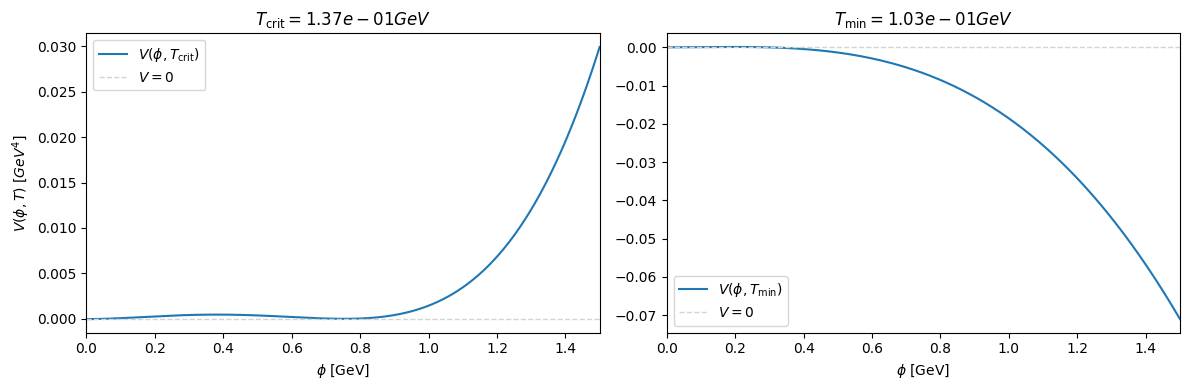

In [33]:
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = False

# Define a plotting range (no vev anymore)
phi = np.linspace(0.0, 1.5, 200)  # adjust if needed

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# -------------------------
# Critical temperature plot
# -------------------------
if T_max is not None:
    v_max = V(phi, T_max)
    axes[0].plot(phi, v_max, label=r'$V(\phi, T_{\mathrm{crit}})$')
    axes[0].set_title(f'$T_{{\\mathrm{{crit}}}} = {T_max:.2e} {units}$')
    axes[0].set_xlim(phi[0], phi[-1])
    axes[0].set_ylabel(f"$V(\\phi, T)$ $[{units}^4]$")

# -------------------------
# Barrier disappearance plot
# -------------------------
if T_min is not None:
    v_min = V(phi, T_min)
    axes[1].plot(phi, v_min, label=r'$V(\phi, T_{\mathrm{min}})$')
    axes[1].set_title(f'$T_{{\\mathrm{{min}}}} = {T_min:.2e} {units}$')
    axes[1].set_xlim(phi[0], phi[-1])

# -------------------------
# Common formatting
# -------------------------
for ax in axes:
    ax.set_xlabel(f"$\\phi$ [{units}]")
    ax.axhline(0.0, color='lightgrey', linestyle='--', linewidth=1, label="$V=0$")
    ax.legend()

plt.tight_layout()
plt.show()

In [34]:
def V(phi, T):
    T_use = max(float(T), T_EPS)

    arr = np.asarray(phi, dtype=float)
    flat = arr.reshape(-1)

    out = np.array([
        dp.V4_equiv(float(x), T_use)
        for x in flat
    ], dtype=float)

    if arr.ndim == 0:
        return float(out[0])

    return out   # IMPORTANT: return 1D array, not (N,1)


def dV(phi, T):
    T_use = max(float(T), T_EPS)

    arr = np.asarray(phi, dtype=float)
    flat = arr.reshape(-1)

    h_rel = 1e-4
    h_abs = 1e-6
    h = h_rel * np.maximum(np.abs(flat), 1.0) + h_abs

    out = np.array([
        (
            dp.V4_equiv(float(x + dx), T_use)
            - dp.V4_equiv(float(x - dx), T_use)
        ) / (2.0 * dx)
        for x, dx in zip(flat, h)
    ], dtype=float)

    if arr.ndim == 0:
        return float(out[0])

    return out   # IMPORTANT: return 1D array

In [35]:
from espinosa import Vt_vec
import numpy as np

true_vev = {}
S3overT = {}
V_min_value = {}
phi0_min = {}
V_exit = {}
false_vev = {}

def action_over_T(T, c_step_phi=1e-3, precision=1e-3):
    T = float(T)

    # Fallback if maxvev was not determined cleanly
    vev0_guess = maxvev

    instance = Vt_vec(
        T,
        V,
        dV,
        step_phi=c_step_phi,
        precision=precision,
        vev0=vev0_guess,
        ratio_vev_step0=50,
    )

    if instance.barrier:
        true_vev[T] = float(instance.true_min)
        false_vev[T] = float(instance.phi_original_false_vev)
        S3overT[T] = float(instance.action_over_T)
        V_min_value[T] = float(instance.min_V)
        phi0_min[T] = float(instance.phi0_min)
        V_exit[T] = float(instance.V_exit)
        return float(instance.action_over_T)
    else:
        return None

In [36]:
import time
import numpy as np

n_points = 100

# Ensure dictionaries are re-initialized as empty before population
true_vev = {}
S3overT = {}
V_min_value = {}
phi0_min = {}
V_exit = {}
false_vev = {}

if T_min is None or T_max is None:
    raise RuntimeError("T_min or T_max is None. Run the temperature finder first and make sure a barrier exists.")

temperatures_scan = np.linspace(float(T_min), float(T_max), n_points)
action_vec = np.vectorize(action_over_T, otypes=[object])

start_time = time.time()
_ = action_vec(temperatures_scan)
end_time = time.time()

print(f"Elapsed time: {end_time - start_time:.2f} seconds")

# Keep only temperatures where the action was successfully computed
temperatures = np.array(
    [float(T) for T in temperatures_scan if float(T) in S3overT],
    dtype=float
)

if len(temperatures) == 0:
    raise RuntimeError("No valid S3/T points were computed. Try increasing the scan range or adjusting step_phi / vev0.")

/tmp/ipykernel_6607/4181260212.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_exit[T] = float(instance.V_exit)


Elapsed time: 67.42 seconds


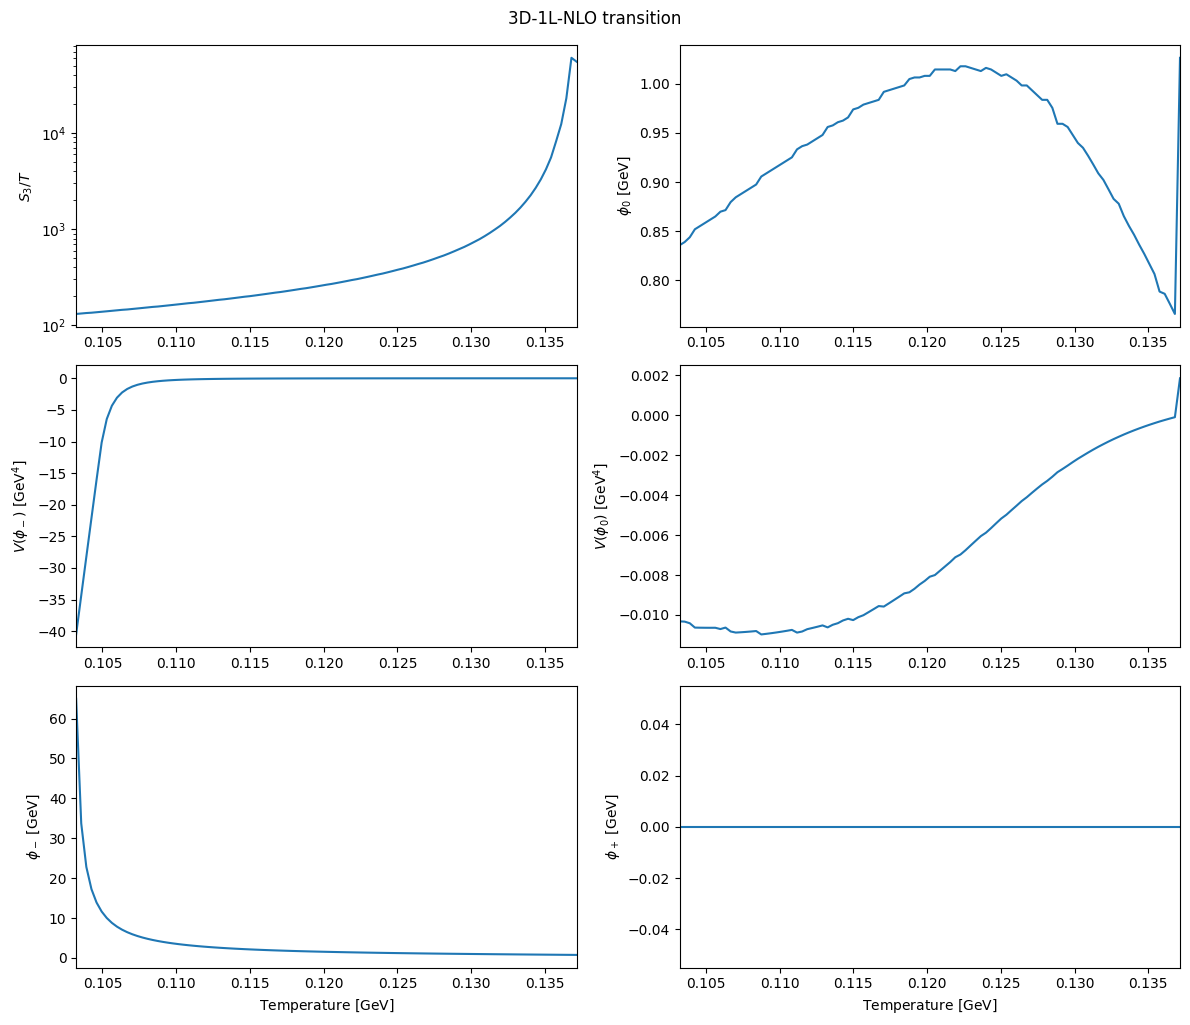

Minimum of the action at T = 1.03e-01 GeV


In [37]:
import matplotlib.pyplot as plt
import os

if len(temperatures) == 0:
    raise RuntimeError("No temperatures available for plotting.")

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

S3_vals      = np.array([S3overT[T] for T in temperatures], dtype=float)
phi0_vals    = np.array([phi0_min[T] for T in temperatures], dtype=float)
Vmin_vals    = np.array([V_min_value[T] for T in temperatures], dtype=float)
Vexit_vals   = np.array([V_exit[T] for T in temperatures], dtype=float)
true_vals    = np.array([true_vev[T] for T in temperatures], dtype=float)
false_vals   = np.array([false_vev[T] for T in temperatures], dtype=float)

axes[0, 0].plot(temperatures, S3_vals)
axes[0, 0].set_ylabel(r'$S_3/T$')
axes[0, 0].set_yscale('log')

axes[0, 1].plot(temperatures, phi0_vals)
axes[0, 1].set_ylabel(f"$\\phi_0\\ \\mathrm{{[{units}]}}$")

axes[1, 0].plot(temperatures, Vmin_vals)
axes[1, 0].set_ylabel(f"$V(\\phi_-)\\ \\mathrm{{[{units}^4]}}$")

axes[1, 1].plot(temperatures, Vexit_vals)
axes[1, 1].set_ylabel(f"$V(\\phi_0)\\ \\mathrm{{[{units}^4]}}$")

axes[2, 0].plot(temperatures, true_vals)
axes[2, 0].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[2, 0].set_ylabel(f"$\\phi_-\\ \\mathrm{{[{units}]}}$")

axes[2, 1].plot(temperatures, false_vals)
axes[2, 1].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[2, 1].set_ylabel(f"$\\phi_+\\ \\mathrm{{[{units}]}}$")

for ax in axes.flatten():
    ax.set_xlim(np.min(temperatures), np.max(temperatures))

plt.tight_layout()
fig.suptitle(f'{description} transition', y=1.02)

# Save only if figure_dir exists
if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"action_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

T_at_min_action = temperatures[np.argmin(S3_vals)]
print(f"Minimum of the action at T = {T_at_min_action:.2e} {units}")

In [38]:
import importlib
import inspect
import numpy as np
import temperatures as temp
from scipy.integrate import cumulative_trapezoid

# ============================================================

# ============================================================
temp = importlib.reload(temp)

# ============================================================

# ============================================================
_sig = inspect.signature(temp.s_SM)
if "units" not in _sig.parameters:
    _real_s_SM = temp.s_SM
    def s_SM(T, units=None):
        return _real_s_SM(T)
    temp.s_SM = s_SM

# ============================================================
# Helper utilities
# ============================================================
def _asfloat(x):
    return float(np.asarray(x, dtype=float).squeeze())

def _ensure_1d(x):
    x = np.asarray(x, dtype=float)
    return x.reshape(-1)

def _phi_safe(phi, floor=1e-12):
    phi = float(np.asarray(phi, dtype=float).squeeze())
    return max(abs(phi), floor)

# ============================================================
# ELENA-like wrapper around your 3D DR model
# ============================================================
class DR3DElenaWrapper:
    def __init__(self, dp, T_floor=1e-12):
        self.dp = dp
        self.T_floor = float(T_floor)

    def Vtot(self, phi, T, include_radiation=True, include_SM=True, units="GeV"):
        phi = np.asarray(phi, dtype=float)
        Teff = max(float(T), self.T_floor)
        out = np.asarray(self.dp.V4_equiv(phi, Teff), dtype=float)
        return out.reshape(-1)

# ============================================================
# Safe compute_logP_f adapted to your mapped 3D potential
# ============================================================
def compute_logP_f_safe(m, V_min_value, S3overT, v_w, units='GeV',
                        cum_method='cumulative_simpson', clip_exp=700.0):

    # Choose cumulative integrator
    if cum_method == 'cumulative_simpson' and hasattr(temp, "cumulative_simpson"):
        cum_f = temp.cumulative_simpson
    else:
        cum_f = cumulative_trapezoid

    # Must provide Vtot(phi,T,...)
    if not hasattr(m, "Vtot"):
        raise AttributeError("Model object passed to compute_logP_f_safe must define Vtot(phi,T,...).")

    V = m.Vtot

    # Only temperatures available in BOTH dictionaries
    Temps = np.array(sorted(set(V_min_value.keys()) & set(S3overT.keys())), dtype=float)
    if Temps.size < 2:
        return np.array([]), Temps, np.array([]), np.array([]), np.array([])

    steps = len(Temps)
    T_step = max((Temps[-1] - Temps[0]) * 1e-3, 1e-8)

    # --------------------------------------------------------
    # Finite-difference derivatives wrt T at fixed phi
    #
    # IMPORTANT:
    # For your mapped 3D potential, the pure SM/radiation T^4
    # piece is not present in V4_equiv in the same ELENA sense.
    # So we do NOT subtract s_SM here.
    # --------------------------------------------------------
    def finite_dVdT(phi, T, step=T_step):
        phi = _phi_safe(phi)
        T = float(T)

        Tm = max(T - step, 1e-12)
        Tp = T + step

        Vm = _asfloat(V(np.array([phi]), Tm, units=units))
        Vp = _asfloat(V(np.array([phi]), Tp, units=units))

        return (Vp - Vm) / (Tp - Tm)

    def finite_d2VdT2(phi, T):
        phi = _phi_safe(phi)
        T = float(T)
        step2 = max(0.5 * T_step, 1e-8)

        Tm = max(T - step2, 1e-12)
        Tp = T + step2

        fm = finite_dVdT(phi, Tm, step2)
        fp = finite_dVdT(phi, Tp, step2)

        return (fp - fm) / (Tp - Tm)

    # --------------------------------------------------------
    # Hubble rate from vacuum + radiation
    # --------------------------------------------------------
    e_vacuum = np.array([-_asfloat(V_min_value[t]) for t in Temps], dtype=float)
    e_radiation = np.pi**2 * temp.g_rho(Temps / temp.convert_units[units]) * Temps**4 / 30.0

    H = np.sqrt(np.maximum(e_vacuum + e_radiation, 0.0) / 3.0) / (
        temp.M_pl * temp.convert_units[units]
    )

    # --------------------------------------------------------
    # Nucleation rate
    # --------------------------------------------------------
    S3_T = np.array([_asfloat(S3overT[t]) for t in Temps], dtype=float)
    S3_clip = np.clip(S3_T, 0.0, clip_exp)

    Gamma = Temps**4 * (np.maximum(S3_T, 0.0) / (2.0 * np.pi))**1.5 * np.exp(-S3_clip)

    # --------------------------------------------------------
    # ratio_V = (d^2V/dT^2)/(dV/dT)
    #
    # Evaluate at a tiny nonzero field to avoid origin issues
    # --------------------------------------------------------
    phi_for_ratio_V = _phi_safe(0.0)

    dVdT_vals = np.array([finite_dVdT(phi_for_ratio_V, T) for T in Temps], dtype=float)
    d2VdT2_vals = np.array([finite_d2VdT2(phi_for_ratio_V, T) for T in Temps], dtype=float)

    ratio_V = d2VdT2_vals / np.where(np.abs(dVdT_vals) > 1e-300, dVdT_vals, np.nan)

    # --------------------------------------------------------
    # False-vacuum fraction
    # --------------------------------------------------------
    logP_f = np.zeros_like(Temps, dtype=float)
    f_ext = ratio_V * Gamma / np.maximum(H, 1e-300)

    for i in range(steps - 1):
        Ts = Temps[i:]
        r = ratio_V[i:]
        Hs = H[i:]
        fE = f_ext[i:]

        cum_ratio_V = cum_f(r, x=Ts, initial=0.0)

        f1 = r / np.maximum(Hs, 1e-300) * np.exp(cum_ratio_V / 3.0)
        cum_f1 = cum_f(f1, x=Ts, initial=0.0)

        f2 = fE * np.exp(-cum_ratio_V) * (cum_f1**3)
        cum_f2 = cum_f(f2, x=Ts, initial=0.0)

        logP_f[i] = -(4.0 / 243.0) * np.pi * (v_w**3) * cum_f2[-1]

    return logP_f, Temps, ratio_V, Gamma, H

# Monkey patch temperatures module
temp.compute_logP_f = compute_logP_f_safe


In [39]:
import numpy as np
from scipy.integrate import cumulative_trapezoid

import temperatures as temp
from dof_interpolation import g_rho
from utils import convert_units

# ============================================================
# Linear crossing helper
# ============================================================
def _crossing_linear(x, y, ystar):
    """
    Return x where y crosses ystar by linear interpolation.
    Assumes x is increasing.
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 2:
        return np.nan

    s = y - ystar
    idx = np.where(s[:-1] * s[1:] <= 0)[0]
    if idx.size == 0:
        return np.nan

    i = idx[0]
    x0, x1 = x[i], x[i + 1]
    y0, y1 = y[i], y[i + 1]

    if y1 == y0:
        return 0.5 * (x0 + x1)

    return x0 + (ystar - y0) * (x1 - x0) / (y1 - y0)

# ============================================================
def compute_logP_f_fixed(V_min_value, S3overT, *, v_w=1.0, units="GeV",
                         use_g_running=True, clip_exp=700.0):

    Temps = np.array(sorted(set(V_min_value.keys()) & set(S3overT.keys())), dtype=float)
    if Temps.size < 3:
        raise RuntimeError("Need at least 3 temperatures with both V_min_value and S3overT.")

    # --------------------------------------------------------
    # Energy densities and Hubble rate
    # --------------------------------------------------------
    e_vac = np.array([-V_min_value[T] for T in Temps], dtype=float)

    g = np.asarray(g_rho(Temps / convert_units[units]), dtype=float)
    e_rad = (np.pi**2 / 30.0) * g * Temps**4

    H = np.sqrt(np.maximum(e_vac + e_rad, 0.0) / 3.0) / (temp.M_pl * convert_units[units])

    # --------------------------------------------------------
    # Nucleation rate
    # --------------------------------------------------------
    S3_T = np.array([S3overT[T] for T in Temps], dtype=float)
    S3_clip = np.clip(S3_T, 0.0, clip_exp)

    Gamma = Temps**4 * (np.maximum(S3_T, 0.0) / (2.0 * np.pi))**1.5 * np.exp(-S3_clip)

    # --------------------------------------------------------
    # ratio_V for radiation-dominated evolution
    # --------------------------------------------------------
    if use_g_running:
        ln_g = np.log(np.maximum(g, 1e-300))
        dln_g_dT = np.gradient(ln_g, Temps)
        ratio_V = 3.0 / Temps + dln_g_dT
    else:
        ratio_V = 3.0 / Temps

    # --------------------------------------------------------
    # False-vacuum fraction
    # --------------------------------------------------------
    logP_f = np.zeros_like(Temps)
    f_ext = ratio_V * Gamma / np.maximum(H, 1e-300)

    for i in range(len(Temps) - 1):
        Ts = Temps[i:]
        r = ratio_V[i:]
        Hs = H[i:]
        fE = f_ext[i:]

        cum_r = cumulative_trapezoid(r, x=Ts, initial=0.0)

        f1 = r / np.maximum(Hs, 1e-300) * np.exp(cum_r / 3.0)
        cum_f1 = cumulative_trapezoid(f1, x=Ts, initial=0.0)

        f2 = fE * np.exp(-cum_r) * cum_f1**3
        cum_f2 = cumulative_trapezoid(f2, x=Ts, initial=0.0)

        logP_f[i] = -(4.0 / 243.0) * np.pi * (v_w**3) * cum_f2[-1]

    return logP_f, Temps, ratio_V, Gamma, H

# ============================================================
# Run and extract milestones
# ============================================================
logP_f, Temps, ratio_V, Gamma, H = compute_logP_f_fixed(
    V_min_value, S3overT, v_w=1.0, units=units, use_g_running=True
)

# Calculate d_dT_logP_f here
d_dT_logP_f = np.gradient(logP_f, Temps)

P_f = np.exp(np.clip(logP_f, -700.0, 0.0))
nH = temp.N_bubblesH(Temps, Gamma, logP_f, H, ratio_V)

print(f"Temps range: {Temps[0]:.6e} -> {Temps[-1]:.6e}   N={len(Temps)}")
print(f"ratio_V range: {np.nanmin(ratio_V):.6e} -> {np.nanmax(ratio_V):.6e}")
print(f"logP_f range: {np.nanmin(logP_f):.6e} -> {np.nanmax(logP_f):.6e}")
print(f"P_f range: {np.nanmin(P_f):.6e} -> {np.nanmax(P_f):.6e}")
print(f"nH range: {np.nanmin(nH):.6e} -> {np.nanmax(nH):.6e}")

T_nuc = _crossing_linear(Temps, nH, 1.0)
T_perc = _crossing_linear(Temps, P_f, 0.71)
T_completion = _crossing_linear(Temps, P_f, 0.01)

print(f"\nT_nuc = {T_nuc} {units}")
print(f"T_perc = {T_perc} {units}")
print(f"T_completion = {T_completion} {units}")

if np.isnan(T_nuc):
    print("Note: No nucleation found in this window. Try extending the T scan.")
if np.isnan(T_perc):
    print("Note: P_f never reached 0.71 in this window.")
if np.isnan(T_completion):
    print("Note: P_f never reached 0.01 in this window.")

Temps range: 1.032137e-01 -> 1.371497e-01   N=99
ratio_V range: 3.155289e+01 -> 3.557094e+01
logP_f range: -7.232771e+03 -> 0.000000e+00
P_f range: 9.859677e-305 -> 1.000000e+00
nH range: -0.000000e+00 -> 9.080109e+06

T_nuc = 0.1102851686338298 GeV
T_perc = 0.10683023250533392 GeV
T_completion = 0.10600625228191615 GeV


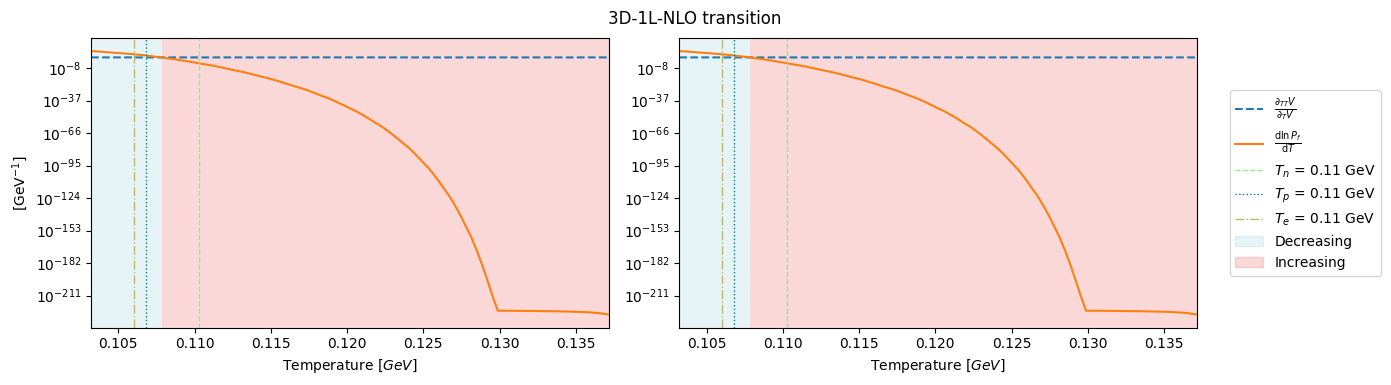

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Basic safety
Temps = np.asarray(Temps, dtype=float)
ratio_V = np.asarray(ratio_V, dtype=float)
d_dT_logP_f = np.asarray(d_dT_logP_f, dtype=float)
mask = np.ones_like(Temps, dtype=bool) # Initialize mask

if len(Temps) < 2:
    raise RuntimeError("Not enough temperature points to make the volume-evolution plot.")

if np.sum(mask) < 2:
    mask = np.ones_like(Temps, dtype=bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full-range plot
axes[0].plot(Temps, ratio_V, label=r'$\frac{\partial_{TT} V}{\partial_T V}$', linestyle='--')
axes[0].plot(Temps, d_dT_logP_f, label=r'$\frac{\mathrm{d} \ln P_f}{\mathrm{d} T}$')
axes[0].set_xlim(Temps[0], Temps[-1])
axes[0].set_ylabel(fr"$\mathrm{{[{units}^{{-1}}]}}$")

# Zoomed plot
axes[1].plot(Temps[mask], ratio_V[mask], label=r'$\frac{\partial_{TT} V}{\partial_T V}$', linestyle='--')
axes[1].plot(Temps[mask], d_dT_logP_f[mask], label=r'$\frac{\mathrm{d} \ln P_f}{\mathrm{d} T}$')
axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])

# Legend patches
decreasing_patch = mpatches.Patch(color='lightblue', alpha=0.3, label='Decreasing')
increasing_patch = mpatches.Patch(color='lightcoral', alpha=0.3, label='Increasing')

# Find intersections between d_dT_logP_f and ratio_V
intersections = []
diff = d_dT_logP_f - ratio_V

for i in range(len(Temps) - 1):
    y1, y2 = diff[i], diff[i + 1]
    x1, x2 = Temps[i], Temps[i + 1]

    if not (np.isfinite(y1) and np.isfinite(y2) and np.isfinite(x1) and np.isfinite(x2)):
        continue

    # exact hit
    if y1 == 0:
        intersections.append(x1)

    # crossing
    elif y1 * y2 < 0:
        denom = (y2 - y1)
        if denom != 0:
            x_cross = x1 - y1 * (x2 - x1) / denom
            if np.isfinite(x_cross):
                intersections.append(x_cross)

# Add precise crossing points to define colored intervals
all_points = np.sort(np.unique(np.concatenate([Temps, np.array(intersections, dtype=float)])))

for ax in axes.flatten():
    ax.set_yscale('log')
    ax.set_xlabel(fr"$\mathrm{{Temperature}}\ [{units}]$")

    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=f'$T_{{n}}$ = {T_nuc:.2f} {units}')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=f'$T_{{p}}$ = {T_perc:.2f} {units}')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=f'$T_{{e}}$ = {T_completion:.2f} {units}')

    # Color intervals using midpoint test
    for i in range(len(all_points) - 1):
        x_left, x_right = all_points[i], all_points[i + 1]
        x_mid = 0.5 * (x_left + x_right)

        d_mid = np.interp(x_mid, Temps, d_dT_logP_f)
        r_mid = np.interp(x_mid, Temps, ratio_V)

        if np.isfinite(d_mid) and np.isfinite(r_mid):
            if d_mid >= r_mid:
                ax.axvspan(x_left, x_right, facecolor='lightblue', alpha=0.3)
            else:
                ax.axvspan(x_left, x_right, facecolor='lightcoral', alpha=0.3)

# Put the legend on the right panel
handles, labels = axes[1].get_legend_handles_labels()
handles.extend([decreasing_patch, increasing_patch])
labels.extend(['Decreasing', 'Increasing'])
axes[1].legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

fig.suptitle(f'{description} transition', y=0.95)
plt.tight_layout()

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"volume_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\ '
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\ '
<>:56: SyntaxWarning: invalid escape sequence '\ '
<>:59: SyntaxWarning: invalid escape sequence '\ '
<>:62: SyntaxWarning: invalid escape sequence '\ '
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\ '
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\ '
<>:56: SyntaxWarning: invalid escape sequence '\ '
<>:59: SyntaxWarning: invalid escape sequence '\ '
<>:62: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_6607/4135002852.py:37: SyntaxWarning: invalid escape sequence '\m'
  axes[1, 0].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
/tmp/ipykernel_6607/4135002852.py:37: SyntaxWarning: invalid escape sequence '\ '
  axes[1, 0].set_xlabel(f"$\mathrm{{Temperature\ [{units}]

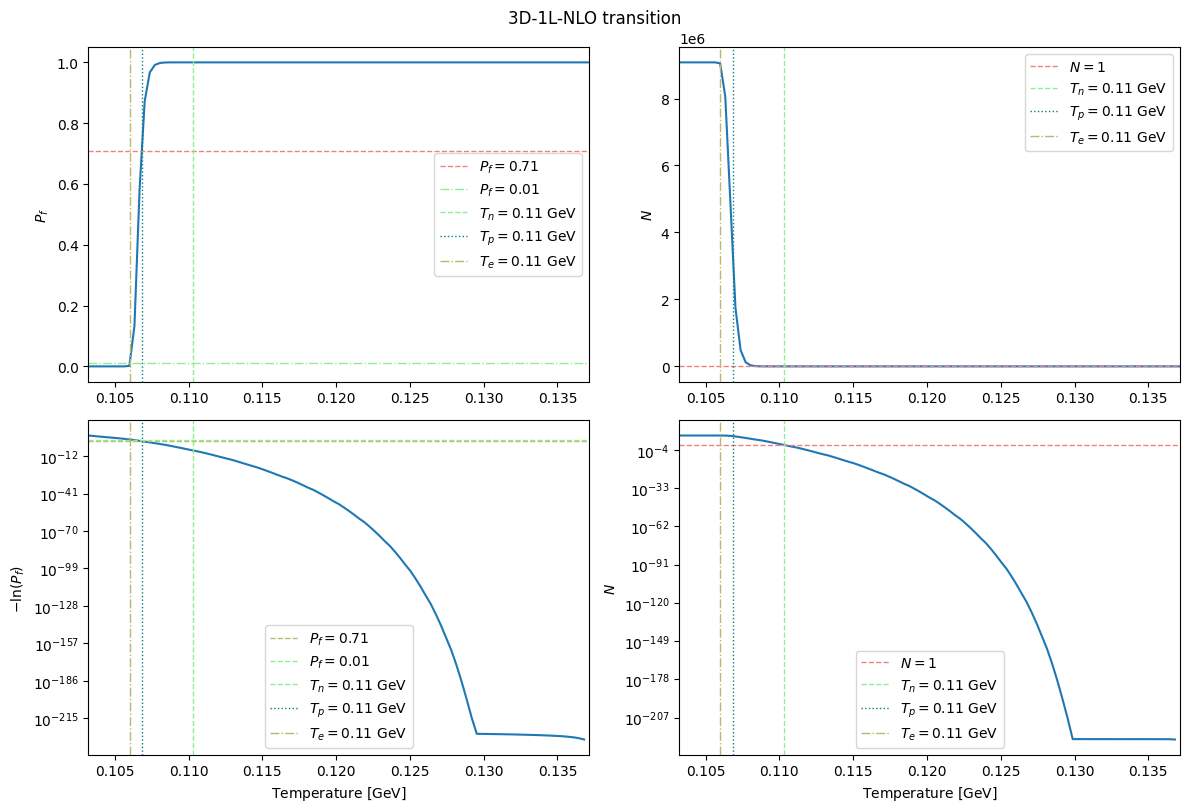

Average number of bubbles at T_min, N = 9.080e+06


In [41]:
import numpy as np
import matplotlib.pyplot as plt
import os

Temps = np.asarray(Temps, dtype=float)
logP_f = np.asarray(logP_f, dtype=float)
nH = np.asarray(nH, dtype=float)
mask_nH = np.isfinite(nH) # Fixed: Initialize mask_nH here

Pf = np.exp(logP_f)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top-left: Pf
axes[0, 0].plot(Temps, Pf)
axes[0, 0].set_ylabel(r'$P_f$')
axes[0, 0].axhline(0.71, color='lightcoral', linestyle='--', linewidth=1, label=r'$P_f = 0.71$')
axes[0, 0].axhline(0.01, color='lightgreen', linestyle='-.', linewidth=1, label=r'$P_f = 0.01$')
axes[0, 0].legend()

# Top-right: N
if np.any(mask_nH):
    axes[0, 1].plot(Temps[mask_nH], nH[mask_nH])
axes[0, 1].axhline(1.0, color='lightcoral', linestyle='--', linewidth=1, label=r'$N = 1$')
axes[0, 1].set_ylabel(r'$N$')
axes[0, 1].legend()

# Bottom-left: -ln(Pf)
minus_logPf = -logP_f
mask_log = np.isfinite(minus_logPf) & (minus_logPf > 0)

if np.any(mask_log):
    axes[1, 0].plot(Temps[mask_log], minus_logPf[mask_log])

axes[1, 0].axhline(-np.log(0.71), color='darkkhaki', linestyle='--', linewidth=1, label=r'$P_f = 0.71$')
axes[1, 0].axhline(-np.log(0.01), color='lightgreen', linestyle='--', linewidth=1, label=r'$P_f = 0.01$')
axes[1, 0].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
axes[1, 0].set_ylabel(r'$-\ln(P_f)$')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()

# Bottom-right: N in log scale
mask_nH_log = np.isfinite(nH) & (nH > 0)
if np.any(mask_nH_log):
    axes[1, 1].plot(Temps[mask_nH_log], nH[mask_nH_log])
axes[1, 1].axhline(1.0, color='lightcoral', linestyle='--', linewidth=1, label=r'$N = 1$')
axes[1, 1].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
axes[1, 1].set_ylabel(r'$N$')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()

# Milestone lines
for ax in axes.flatten():
    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=f'$T_{{n}} = {T_nuc:.2f}\ \mathrm{{{units}}}$')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=f'$T_{{p}} = {T_perc:.2f}\ \mathrm{{{units}}}$')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=f'$T_{{e}} = {T_completion:.2f}\ \mathrm{{{units}}}$')
    ax.set_xlim(Temps[0], Temps[-1])
    ax.legend()

plt.tight_layout()
fig.suptitle(f'{description} transition', y=1.01)

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"evolution_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

if np.any(mask_nH):
    print(f"Average number of bubbles at T_min, N = {nH[mask_nH][0]:.3e}")
else:
    print("Average number of bubbles at T_min, N = nan")

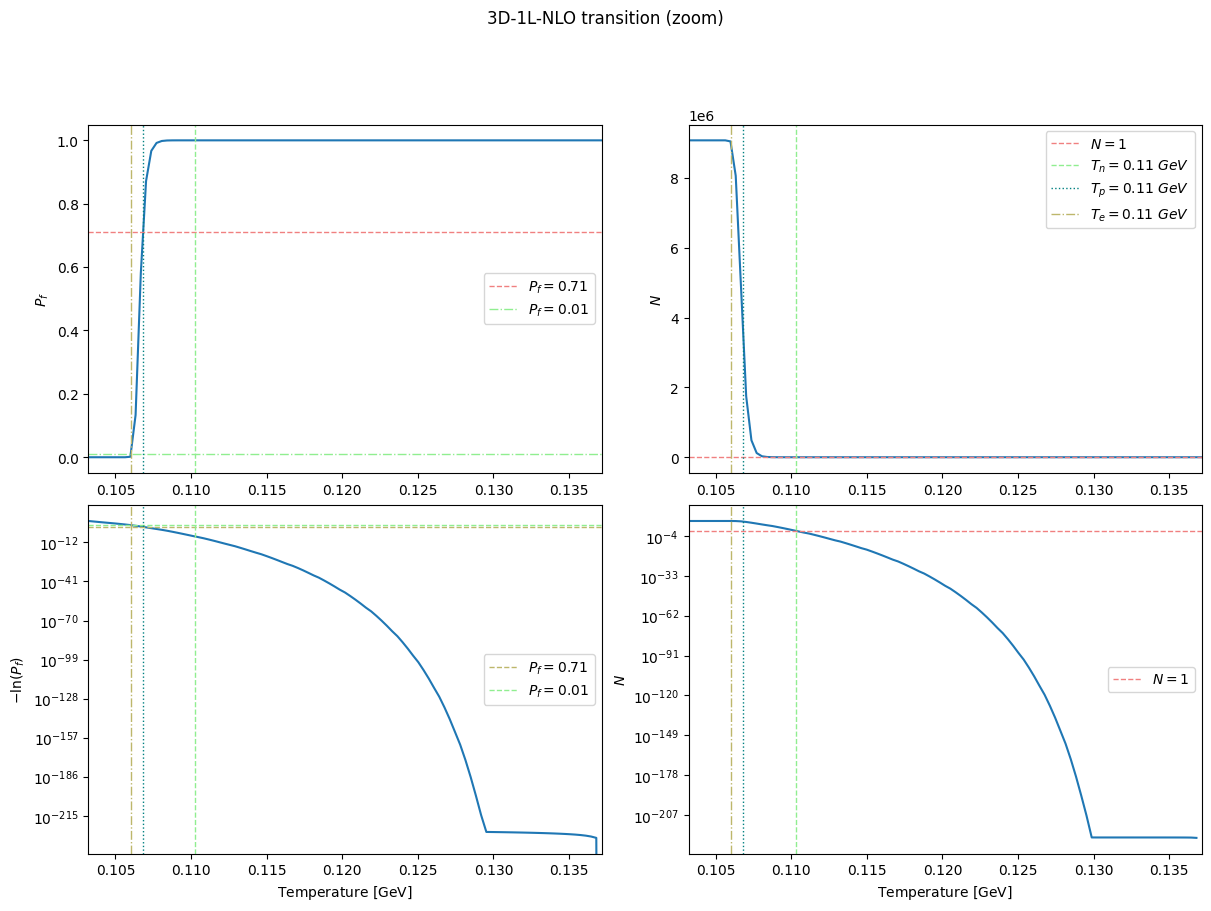

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import os

# assumes you already have:
# Temps, logP_f, nH, mask, T_nuc, T_perc, T_completion, units, description, figure_dir

os.makedirs(figure_dir, exist_ok=True)

# zoom arrays
Tz = Temps[mask]
logPz = logP_f[mask]
nHz = nH[mask]

# plotting-safe Pf
Pfz = np.exp(np.clip(logPz, -700.0, 0.0))

# for log-plot of N: keep only positive finite values
mask_nH_pos = np.isfinite(nHz) & (nHz > 0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# Pf (linear)
axes[0,0].plot(Tz, Pfz)
axes[0,0].set_ylabel(r"$P_f$")
axes[0,0].axhline(0.71, color="lightcoral", linestyle="--", linewidth=1, label=r"$P_f=0.71$")
axes[0,0].axhline(0.01, color="lightgreen", linestyle="-.", linewidth=1, label=r"$P_f=0.01$")
axes[0,0].legend()

# N (linear)
axes[0,1].plot(Tz, nHz)
axes[0,1].axhline(1, color="lightcoral", linestyle="--", linewidth=1, label=r"$N=1$")
axes[0,1].set_ylabel(r"$N$")
axes[0,1].legend()

# -log Pf (log y)
axes[1,0].plot(Tz, -logPz)
axes[1,0].axhline(-np.log(0.71), color="darkkhaki", linestyle="--", linewidth=1, label=r"$P_f=0.71$")
axes[1,0].axhline(-np.log(0.01), color="lightgreen", linestyle="--", linewidth=1, label=r"$P_f=0.01$")
axes[1,0].set_xlabel(rf"$\mathrm{{Temperature\ [{units}]}}$")
axes[1,0].set_ylabel(r"$-\ln(P_f)$")
axes[1,0].set_yscale("log")
axes[1,0].legend()

# N (log y) – use positive points only
axes[1,1].plot(Tz[mask_nH_pos], nHz[mask_nH_pos])
axes[1,1].axhline(1, color="lightcoral", linestyle="--", linewidth=1, label=r"$N=1$")
axes[1,1].set_xlabel(rf"$\mathrm{{Temperature\ [{units}]}}$")
axes[1,1].set_ylabel(r"$N$")
axes[1,1].set_yscale("log")
axes[1,1].legend()

# milestone vertical lines (avoid duplicating legend spam)
for ax in axes.flatten():
    ax.axvline(T_nuc,        color="lightgreen", linestyle="--", linewidth=1)
    ax.axvline(T_perc,       color="teal",       linestyle=":",  linewidth=1)
    ax.axvline(T_completion, color="darkkhaki",  linestyle="-.", linewidth=1)
    ax.set_xlim(Tz[0], Tz[-1])

# add one milestone legend (clean) in top-right panel
milestone_handles = [
    plt.Line2D([0],[0], color="lightgreen", linestyle="--", linewidth=1, label=rf"$T_n={T_nuc:.2f}\ {units}$"),
    plt.Line2D([0],[0], color="teal",       linestyle=":",  linewidth=1, label=rf"$T_p={T_perc:.2f}\ {units}$"),
    plt.Line2D([0],[0], color="darkkhaki",  linestyle="-.", linewidth=1, label=rf"$T_e={T_completion:.2f}\ {units}$"),
]
h0, l0 = axes[0,1].get_legend_handles_labels()
axes[0,1].legend(h0 + milestone_handles, l0 + [h.get_label() for h in milestone_handles], loc="best")

fig.suptitle(f"{description} transition (zoom)", y=1.12)
plt.savefig(os.path.join(figure_dir, f"evolution_{description}_zoom.pdf"), dpi=300, bbox_inches="tight")
plt.show()


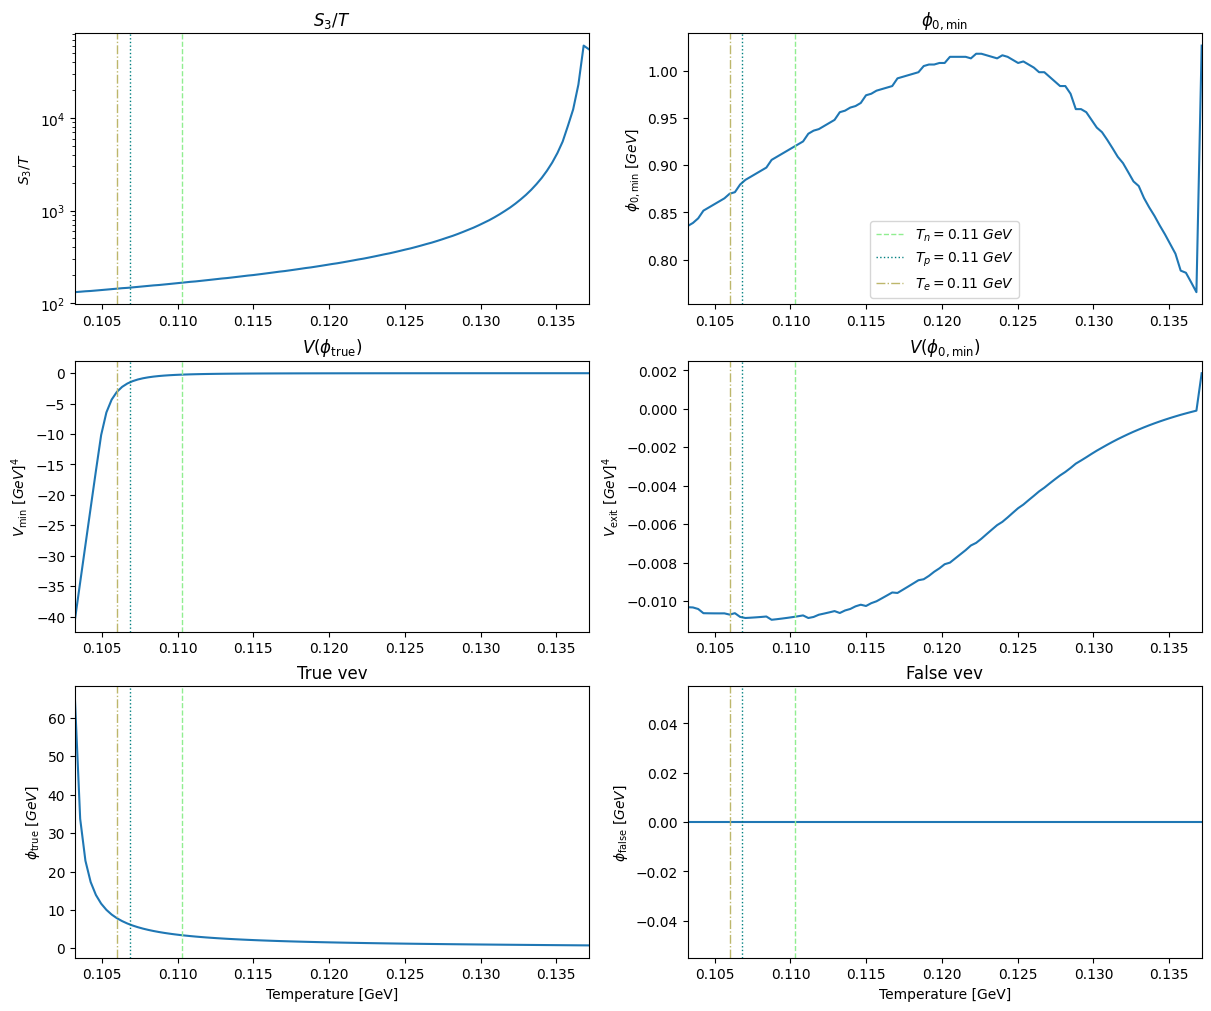

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# assumes you already have:
# Temps, mask, units, T_nuc, T_perc, T_completion
# dicts: S3overT, phi0_min, V_min_value, V_exit, true_vev, false_vev

Tz = np.asarray(Temps[mask], float)

def vec_from_dict(d, Tgrid):
    out = np.full_like(Tgrid, np.nan, dtype=float)
    for i, T in enumerate(Tgrid):
        # keys are floats; try exact then nearest fallback
        if T in d:
            out[i] = d[T]
        else:
            # nearest key fallback (safe for float rounding issues)
            ks = np.asarray(list(d.keys()), float)
            j = int(np.argmin(np.abs(ks - T)))
            out[i] = d[float(ks[j])]
    return out

S3z   = vec_from_dict(S3overT,    Tz)
phi0z = vec_from_dict(phi0_min,   Tz)
Vminz = vec_from_dict(V_min_value,Tz)
Vexz  = vec_from_dict(V_exit,     Tz)
phit  = vec_from_dict(true_vev,   Tz)
phif  = vec_from_dict(false_vev,  Tz)

fig, axes = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)

axes[0,0].plot(Tz, np.clip(S3z, 1e-300, None))
axes[0,0].set_title(r"$S_3/T$")
axes[0,0].set_ylabel(r"$S_3/T$")
axes[0,0].set_yscale("log")

axes[0,1].plot(Tz, phi0z)
axes[0,1].set_title(r"$\phi_{0,\mathrm{min}}$")
axes[0,1].set_ylabel(rf"$\phi_{{0,\mathrm{{min}}}}\ [{units}]$")

axes[1,0].plot(Tz, Vminz)
axes[1,0].set_title(r"$V(\phi_{\rm true})$")
axes[1,0].set_ylabel(rf"$V_{{\mathrm{{min}}}}\ [{units}]^4$")

axes[1,1].plot(Tz, Vexz)
axes[1,1].set_title(r"$V(\phi_{0,\mathrm{min}})$")
axes[1,1].set_ylabel(rf"$V_{{\mathrm{{exit}}}}\ [{units}]^4$")

axes[2,0].plot(Tz, phit)
axes[2,0].set_title("True vev")
axes[2,0].set_xlabel(rf"Temperature [{units}]")
axes[2,0].set_ylabel(rf"$\phi_{{\mathrm{{true}}}}\ [{units}]$")

axes[2,1].plot(Tz, phif)
axes[2,1].set_title("False vev")
axes[2,1].set_xlabel(rf"Temperature [{units}]")
axes[2,1].set_ylabel(rf"$\phi_{{\mathrm{{false}}}}\ [{units}]$")

# milestone handles (single clean legend style)
milestone_handles = [
    plt.Line2D([0],[0], color="lightgreen", linestyle="--", linewidth=1, label=rf"$T_n={T_nuc:.2f}\ {units}$"),
    plt.Line2D([0],[0], color="teal",       linestyle=":",  linewidth=1, label=rf"$T_p={T_perc:.2f}\ {units}$"),
    plt.Line2D([0],[0], color="darkkhaki",  linestyle="-.", linewidth=1, label=rf"$T_e={T_completion:.2f}\ {units}$"),
]

for ax in axes.flatten():
    ax.axvline(T_nuc,        color="lightgreen", linestyle="--", linewidth=1)
    ax.axvline(T_perc,       color="teal",       linestyle=":",  linewidth=1)
    ax.axvline(T_completion, color="darkkhaki",  linestyle="-.", linewidth=1)
    ax.set_xlim(Tz[0], Tz[-1])

# put the milestone legend once (top-right panel)
axes[0,1].legend(handles=milestone_handles, loc="best")

plt.show()


In [46]:
import types
import numpy as np

def _V_any(self, phi, T, units="GeV"):
    if hasattr(self, "Vtot"):
        return self.Vtot(phi, T, units=units)
    return self.V(phi, T)

def dVdT_3d(self, phi, T, include_radiation=True, include_SM=True, units="GeV"):
    phi = np.asarray(phi, dtype=float)
    T = float(T)

    T_floor = getattr(self, "T_floor", 1e-12)

    h = max(1e-5 * abs(T), 1e-8)
    Tm = max(T - h, T_floor)
    Tp = T + h

    Vm = np.asarray(_V_any(self, phi, Tm, units=units), dtype=float)
    Vp = np.asarray(_V_any(self, phi, Tp, units=units), dtype=float)

    return np.squeeze((Vp - Vm) / (Tp - Tm))


def d2VdT2_3d(self, phi, T, include_radiation=True, include_SM=True, units="GeV"):
    phi = np.asarray(phi, dtype=float)
    T = float(T)

    T_floor = getattr(self, "T_floor", 1e-12)

    h = max(1e-4 * abs(T), 1e-7)
    Tm = max(T - h, T_floor)
    Tp = T + h

    V0 = np.asarray(_V_any(self, phi, T,  units=units), dtype=float)
    Vm = np.asarray(_V_any(self, phi, Tm, units=units), dtype=float)
    Vp = np.asarray(_V_any(self, phi, Tp, units=units), dtype=float)

    return np.squeeze((Vp - 2.0 * V0 + Vm) / h**2)


dp.dVdT = types.MethodType(dVdT_3d, dp)
dp.d2VdT2 = types.MethodType(d2VdT2_3d, dp)

In [47]:
def V(phi, T, *args, **kwargs):
    T_use = max(float(T), T_EPS)

    arr = np.asarray(phi, dtype=float)
    flat = arr.reshape(-1)

    out = np.array([
        dp.V4_equiv(float(x), T_use)
        for x in flat
    ], dtype=float)

    if arr.ndim == 0:
        return float(out[0])

    return out


def dV(phi, T, *args, **kwargs):
    T_use = max(float(T), T_EPS)

    arr = np.asarray(phi, dtype=float)
    flat = arr.reshape(-1)

    h_rel = 1e-4
    h_abs = 1e-6
    h = h_rel * np.maximum(np.abs(flat), 1.0) + h_abs

    out = np.array([
        (
            dp.V4_equiv(float(x + dx), T_use)
            - dp.V4_equiv(float(x - dx), T_use)
        ) / (2.0 * dx)
        for x, dx in zip(flat, h)
    ], dtype=float)

    if arr.ndim == 0:
        return float(out[0])

    return out

/tmp/ipykernel_6607/4181260212.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_exit[T] = float(instance.V_exit)


c_s^2(T_perc) = -7.666419e-01


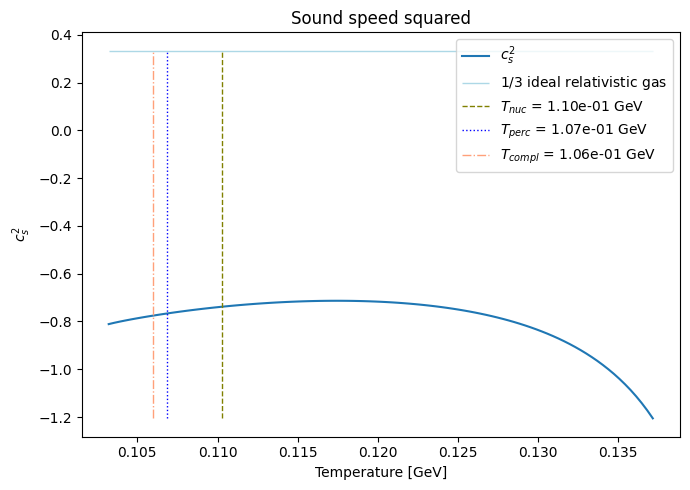

In [48]:
from GWparams import cs2
import numpy as np
import matplotlib.pyplot as plt

# Make sure dp has ELENA-style potential methods
dp.Vtot = V
dp.DVtot = V
dp.gradV = dV

# Ensure true_vev contains T_perc
if T_perc is not None:
    action_over_T(T_perc)
    c_s2 = cs2(T_perc, dp, true_vev, units=units)
    print(f"c_s^2(T_perc) = {c_s2:.6e}")

# Compute c_s^2 over valid temperatures only
y = []

for T in Temps:
    T = float(T)

    if T not in true_vev:
        action_over_T(T)

    try:
        y.append(cs2(T, dp, true_vev, units=units))
    except Exception:
        y.append(np.nan)

y = np.array(y, dtype=float)

plt.figure(figsize=(7, 5))

plt.plot(Temps, y, label=r"$c_s^2$")

plt.hlines(
    1 / 3,
    Temps[0],
    Temps[-1],
    color="lightblue",
    linestyle="-",
    linewidth=1,
    label=r"$1/3$ ideal relativistic gas",
)

ymin = np.nanmin(y)
ymax = np.nanmax([np.nanmax(y), (1 + 1e-4) / 3])

if T_nuc is not None:
    plt.vlines(
        T_nuc,
        ymin,
        ymax,
        color="olive",
        linestyle="--",
        linewidth=1,
        label=fr"$T_{{nuc}}$ = {T_nuc:.2e} {units}",
    )

if T_perc is not None:
    plt.vlines(
        T_perc,
        ymin,
        ymax,
        color="blue",
        linestyle=":",
        linewidth=1,
        label=fr"$T_{{perc}}$ = {T_perc:.2e} {units}",
    )

if T_completion is not None:
    plt.vlines(
        T_completion,
        ymin,
        ymax,
        color="lightsalmon",
        linestyle="-.",
        linewidth=1,
        label=fr"$T_{{compl}}$ = {T_completion:.2e} {units}",
    )

plt.title("Sound speed squared")
plt.xlabel(f"Temperature [{units}]")
plt.ylabel(r"$c_s^2$")
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
from GWparams import alpha_th_bar # This is the definition of \alpha

def c_alpha_inf(T, units):
    # Use model parameters from dp object
    g_model = dp.g1_0 # g1_0 is the initial gauge coupling
    lam_model = dp.lam_0 # lam_0 is the initial quartic coupling

    v_true = true_vev[T]
    v_false = false_vev[T]
    Dm2_photon = 3 * g_model**2 * (v_true**2 - v_false**2)
    Dm2_scalar = 3 * lam_model * (v_true**2 - v_false**2)
    numerator = (Dm2_photon + Dm2_scalar) * T**2 / 24
    rho_tot = - T * 3 * (dp.dVdT(v_false, T, include_radiation=True, include_SM = True, units = units) ) / 4
    rho_DS = - T * 3 * (dp.dVdT(v_false, T, include_radiation=True, include_SM = False, units = units) ) / 4
    return numerator/ rho_tot, numerator / rho_DS

def c_alpha_eq(T, units):
    # Use model parameters from dp object
    g_model = dp.g1_0 # g1_0 is the initial gauge coupling
    lam_model = dp.lam_0 # lam_0 is the initial quartic coupling

    v_true = true_vev[T]
    v_false = false_vev[T]
    numerator = (g_model**2 * 3 * (g_model * (v_true - v_false)) * T**3)
    rho_tot = - T * 3 * (dp.dVdT(v_false, T, include_radiation=True, include_SM = True, units = units) ) / 4
    rho_DS = - T * 3 * (dp.dVdT(v_false, T, include_radiation=True, include_SM = False, units = units) ) / 4
    return numerator / rho_tot, numerator / rho_DS

In [50]:
alpha, alpha_DS = alpha_th_bar(T_perc, dp, V_min_value, false_vev, true_vev, units = units)
alpha_inf, alpha_inf_DS = c_alpha_inf(T_perc, units)
alpha_eq, alpha_eq_DS = c_alpha_eq(T_perc, units)

gamma_eq = (alpha - alpha_inf) / alpha_eq
print(f"alpha = {alpha}")
print(f"alpha_inf = {alpha_inf}")
print(f"alpha_eq = {alpha_eq}")
print(f"gamma_eq = {gamma_eq}")

is_physical = True # Initialize is_physical

if alpha < alpha_inf:
    is_physical = False
    print("\n*** Warning, the bubble expansion is not in runaway regime! The results of the computation are not reliable ***")

v_min = 0.99

if gamma_eq < 1 / np.sqrt(1 - v_min**2):
    is_physical = False
    print(f"\n*** Warning, the NLO pressure could prevent the walls to reach relativistic velocities (gamma_eq = {gamma_eq:.2e}). The results of the computation are not reliable ***")

alpha = 800329.1631777401
alpha_inf = 4260.371313352484
alpha_eq = 2985.90363129526
gamma_eq = 266.60900355952197


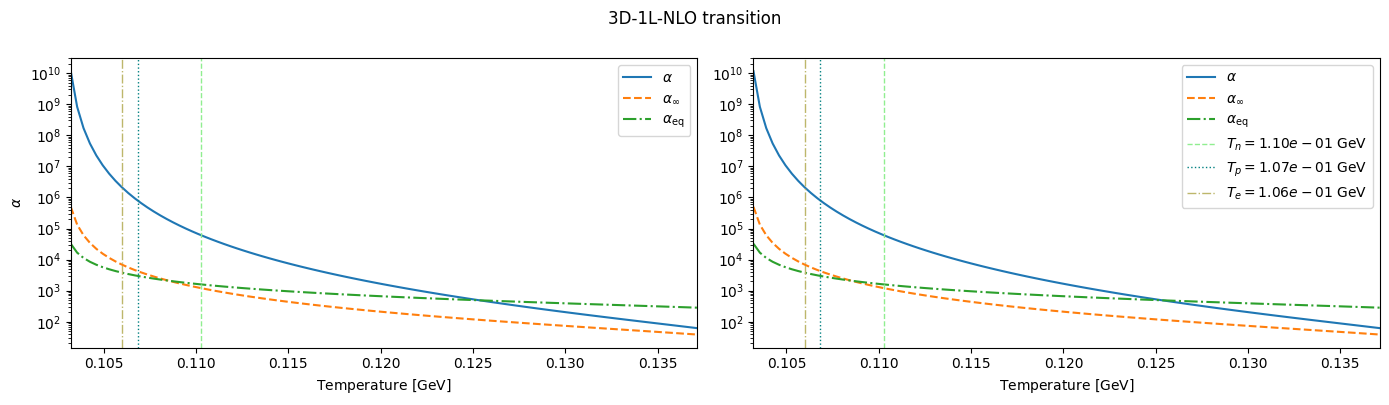

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import os

def scalar(x):
    return float(np.asarray(x, dtype=float).squeeze())

def valid_T(T):
    return (
        np.isfinite(T)
        and T in V_min_value
        and T in false_vev
        and T in true_vev
    )

alpha_T = np.full_like(Temps, np.nan, dtype=float)
alpha_inf_T = np.full_like(Temps, np.nan, dtype=float)
alpha_eq_T = np.full_like(Temps, np.nan, dtype=float)

for i, T in enumerate(Temps):
    T = float(T)

    if not valid_T(T):
        continue

    try:
        alpha_T[i] = scalar(
            alpha_th_bar(T, dp, V_min_value, false_vev, true_vev, units=units)[0]
        )
        alpha_inf_T[i] = scalar(c_alpha_inf(T, units)[0])
        alpha_eq_T[i] = scalar(c_alpha_eq(T, units)[0])
    except Exception as e:
        print(f"Skipping T={T:.6e}: {e}")

mask = np.asarray(mask, dtype=bool)
if np.sum(mask) < 2:
    mask = np.ones_like(Temps, dtype=bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(Temps, alpha_T, label=r'$\alpha$', linestyle='-')
axes[0].plot(Temps, alpha_inf_T, label=r'$\alpha_\infty$', linestyle='--')
axes[0].plot(Temps, alpha_eq_T, label=r'$\alpha_{\mathrm{eq}}$', linestyle='-.')
axes[0].set_xlabel(rf"$\mathrm{{Temperature\ [{units}]}}$")
axes[0].set_ylabel(r'$\alpha$')
axes[0].set_yscale('log')
axes[0].set_xlim(Temps[0], Temps[-1])

axes[1].plot(Temps[mask], alpha_T[mask], label=r'$\alpha$', linestyle='-')
axes[1].plot(Temps[mask], alpha_inf_T[mask], label=r'$\alpha_\infty$', linestyle='--')
axes[1].plot(Temps[mask], alpha_eq_T[mask], label=r'$\alpha_{\mathrm{eq}}$', linestyle='-.')
axes[1].set_xlabel(rf"$\mathrm{{Temperature\ [{units}]}}$")
axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])

positive_zoom = np.concatenate([
    alpha_T[mask],
    alpha_inf_T[mask],
    alpha_eq_T[mask],
])
positive_zoom = positive_zoom[np.isfinite(positive_zoom) & (positive_zoom > 0)]

if len(positive_zoom) > 0:
    if np.nanmax(positive_zoom) / np.nanmin(positive_zoom) > 5:
        axes[1].set_yscale('log')

for ax in axes.flatten():
    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1)
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1)
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1)

handles, labels = axes[1].get_legend_handles_labels()

milestone_handles = []
if np.isfinite(T_nuc):
    milestone_handles.append(
        plt.Line2D([0], [0], color='lightgreen', linestyle='--', linewidth=1,
                   label=fr'$T_n = {T_nuc:.2e}\ \mathrm{{{units}}}$')
    )
if np.isfinite(T_perc):
    milestone_handles.append(
        plt.Line2D([0], [0], color='teal', linestyle=':', linewidth=1,
                   label=fr'$T_p = {T_perc:.2e}\ \mathrm{{{units}}}$')
    )
if np.isfinite(T_completion):
    milestone_handles.append(
        plt.Line2D([0], [0], color='darkkhaki', linestyle='-.', linewidth=1,
                   label=fr'$T_e = {T_completion:.2e}\ \mathrm{{{units}}}$')
    )

axes[0].legend()
axes[1].legend(handles + milestone_handles,
               labels + [h.get_label() for h in milestone_handles],
               loc='best')

fig.suptitle(f'{description} transition', y=1.00)
plt.tight_layout()

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"alpha_{description}.pdf"),
                dpi=300, bbox_inches='tight')

plt.show()

In [52]:
from temperatures import R_sepH
import numpy as np # Import numpy for np.interp

RH, R = R_sepH(Temps, Gamma, logP_f, H, ratio_V)
# Replace interpolation_narrow with np.interp for linear interpolation
RH_interp = np.interp(T_perc, Temps, RH)
H_star = np.interp(T_perc, Temps, H)
R_star = RH_interp / H_star

print(f"R* H* = {RH_interp:.2e}")

R* H* = 1.20e-02


/content/ELENA/src/temperatures.py:433: RuntimeWarning: divide by zero encountered in power
  return n**(-1/3) * H, n**(-1/3)


<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\ '
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\ '
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence

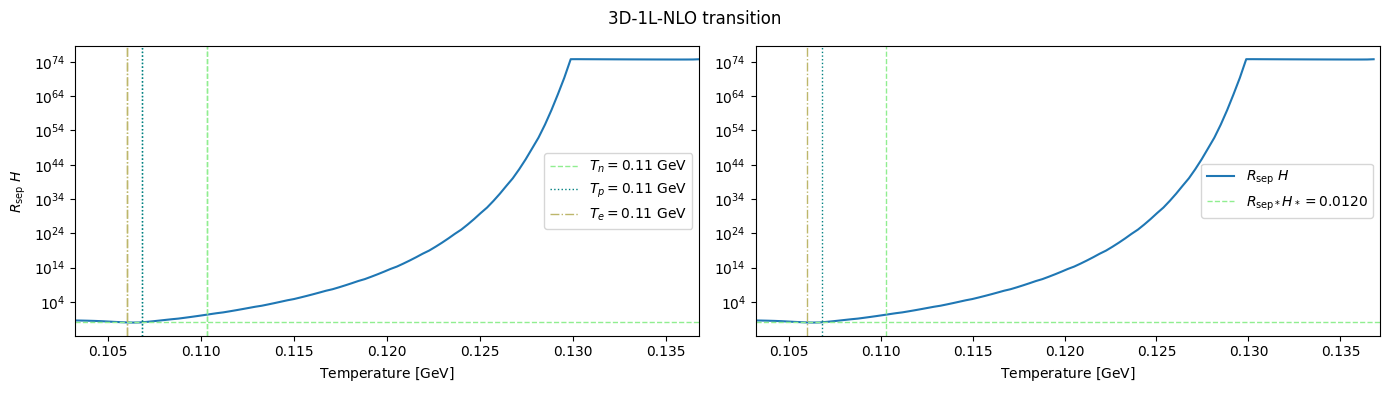

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(Temps, RH) #, label = '$R H$')
axes[0].set_ylabel('$R_\mathrm{sep}\ H$')
axes[0].set_yscale('log')
axes[0].axhline(RH_interp, color='lightgreen', linestyle='--', linewidth=1) #, label=f'$R_* H_* = {RH_interp:.4f}$')
axes[0].axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}} = {T_nuc:.2f} \mathrm{{\ {units}}}$')
axes[0].axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}} = {T_perc:.2f} \mathrm{{\ {units}}}$')
axes[0].axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}} = {T_completion:.2f} \mathrm{{\ {units}}}$')
axes[0].set_xlim(Temps[0], Temps[np.max(np.where(RH < np.inf)[0])])
axes[0].legend()

axes[1].plot(Temps[mask], RH[mask], label = '$R_\mathrm{sep}\ H$')
#axes[1].set_ylabel('$R\ H$')
axes[1].set_yscale('log')
axes[1].axhline(RH_interp, color='lightgreen', linestyle='--', linewidth=1, label=f'$R_\mathrm{{sep *}} H_* = {RH_interp:.4f}$')
axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])
axes[1].legend()

for ax in axes.flatten():
    ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}}$ = {T_nuc:.2e} {units}')
    ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}}$ = {T_perc:.2e} {units}')
    ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}}$ = {T_completion:.2e} {units}')
    ax.set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")

# handles, labels = axes[1].get_legend_handles_labels()
# axes[1].legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

#fig.suptitle(f'Mean bubble separation - {description}')
fig.suptitle(f'{description} transition', y=0.97)
plt.savefig(figure_dir + f"RH_{description}.pdf", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

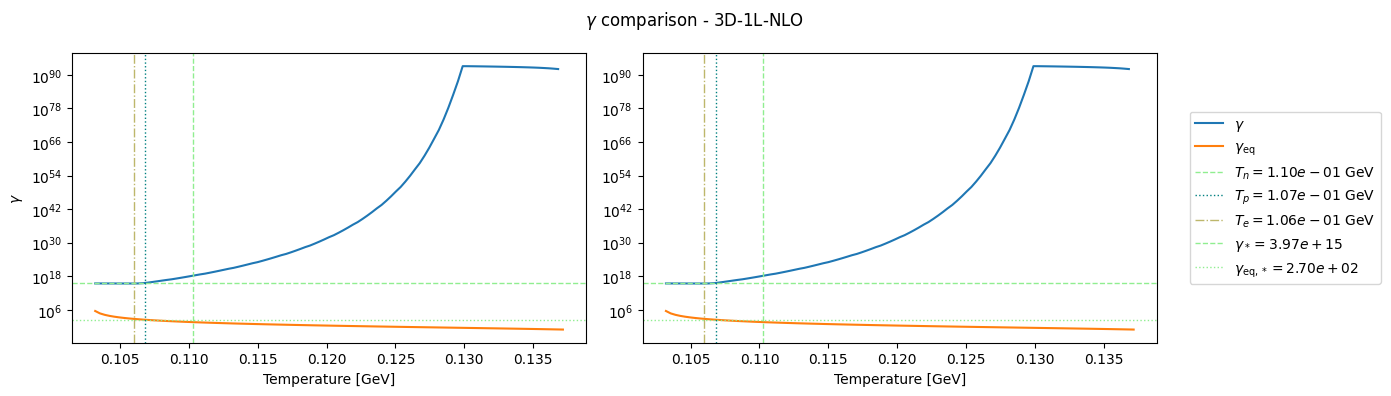

In [54]:
from utils import interpolation_narrow
import numpy as np
import matplotlib.pyplot as plt

def scalar(x):
    return float(np.asarray(x).squeeze())

def R0_safe(T, S3_T, V_exit):
    T = float(T)
    E0V = scalar(S3_T[T]) * T
    DV = -scalar(V_exit[T])
    if DV <= 0 or not np.isfinite(DV):
        return np.nan
    return (3.0 * E0V / (4.0 * np.pi * DV))**(1.0 / 3.0)

r0 = np.array([
    R0_safe(float(T), S3overT, V_exit)
    for T in Temps
], dtype=float)

gamma_eq_T = (alpha_T - alpha_inf_T) / alpha_eq_T

R = np.asarray(R, dtype=float)
gamma = 2.0 * R / (3.0 * r0)

R_star = scalar(interpolation_narrow(Temps, R, T_perc))
r0_star = R0_safe(float(T_perc), S3overT, V_exit)

gamma_star = 2.0 * R_star / (3.0 * r0_star)
gamma_eq_star = scalar(interpolation_narrow(Temps, gamma_eq_T, T_perc))

mask = np.asarray(mask, dtype=bool)
if np.sum(mask) < 2:
    mask = np.ones_like(Temps, dtype=bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(Temps, gamma, label=r'$\gamma$')
axes[0].plot(Temps, gamma_eq_T, label=r'$\gamma_{\mathrm{eq}}$')
axes[0].set_yscale('log')
axes[0].set_xlabel(f'Temperature [{units}]')
axes[0].set_ylabel(r'$\gamma$')

axes[1].plot(Temps[mask], gamma[mask], label=r'$\gamma$')
axes[1].plot(Temps[mask], gamma_eq_T[mask], label=r'$\gamma_{\mathrm{eq}}$')
axes[1].set_yscale('log')
axes[1].set_xlabel(f'Temperature [{units}]')

for ax in axes.flatten():
    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=fr'$T_n = {T_nuc:.2e}\ \mathrm{{{units}}}$')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=fr'$T_p = {T_perc:.2e}\ \mathrm{{{units}}}$')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=fr'$T_e = {T_completion:.2e}\ \mathrm{{{units}}}$')

    if np.isfinite(gamma_star):
        ax.axhline(gamma_star, color='lightgreen', linestyle='--', linewidth=1,
                   label=fr'$\gamma_* = {gamma_star:.2e}$')
    if np.isfinite(gamma_eq_star):
        ax.axhline(gamma_eq_star, color='lightgreen', linestyle=':', linewidth=1,
                   label=fr'$\gamma_{{\mathrm{{eq}},*}} = {gamma_eq_star:.2e}$')

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

fig.suptitle(fr'$\gamma$ comparison - {description}')
plt.tight_layout()
plt.show()

In [55]:
from model_3d import AbelianHiggsDR3D
import types

dp_raw = AbelianHiggsDR3D(
    g1_0=1.7,
    lam_0=0.0,
    msq_0=0.0,
    mu0=1.0,
    Yphi=1.0,
    scheme="3D-1L-NLO",
    use_running=True,
)

dp = DR3DElenaWrapper(dp_raw)

dp.dVdT = types.MethodType(dVdT_3d, dp)
dp.d2VdT2 = types.MethodType(d2VdT2_3d, dp)

print(type(dp_raw))
print(type(dp))
print(hasattr(dp_raw, "V4_equiv"))
print(hasattr(dp, "Vtot"))

<class 'model_3d.AbelianHiggsDR3D'>
<class '__main__.DR3DElenaWrapper'>
True
True


In [56]:
from GWparams import beta
import temperatures as temp

# make sure dp is the wrapper
dp = DR3DElenaWrapper(dp_raw)

# reattach thermal derivatives if needed
dp.dVdT = types.MethodType(dVdT_3d, dp)
dp.d2VdT2 = types.MethodType(d2VdT2_3d, dp)

logP_f, Temps, ratio_V, Gamma, H = temp.compute_logP_f(
    dp,
    V_min_value,
    S3overT,
    v_w=1,
    units=units,
    cum_method='None'
)

beta_Hn, gamma_Hn, times, Gamma_t, Temps_t, H_t = beta(
    Temps,
    ratio_V,
    Gamma,
    H,
    T_nuc,
    T_perc,
    verbose=True
)

print("beta =", beta_Hn)
print("gamma =", gamma_Hn)

beta = 614.0077205203194
gamma = nan


/content/ELENA/src/GWparams.py:46: RuntimeWarning: invalid value encountered in sqrt
  gamma_Hn = np.sqrt(- 2 * b_fit)


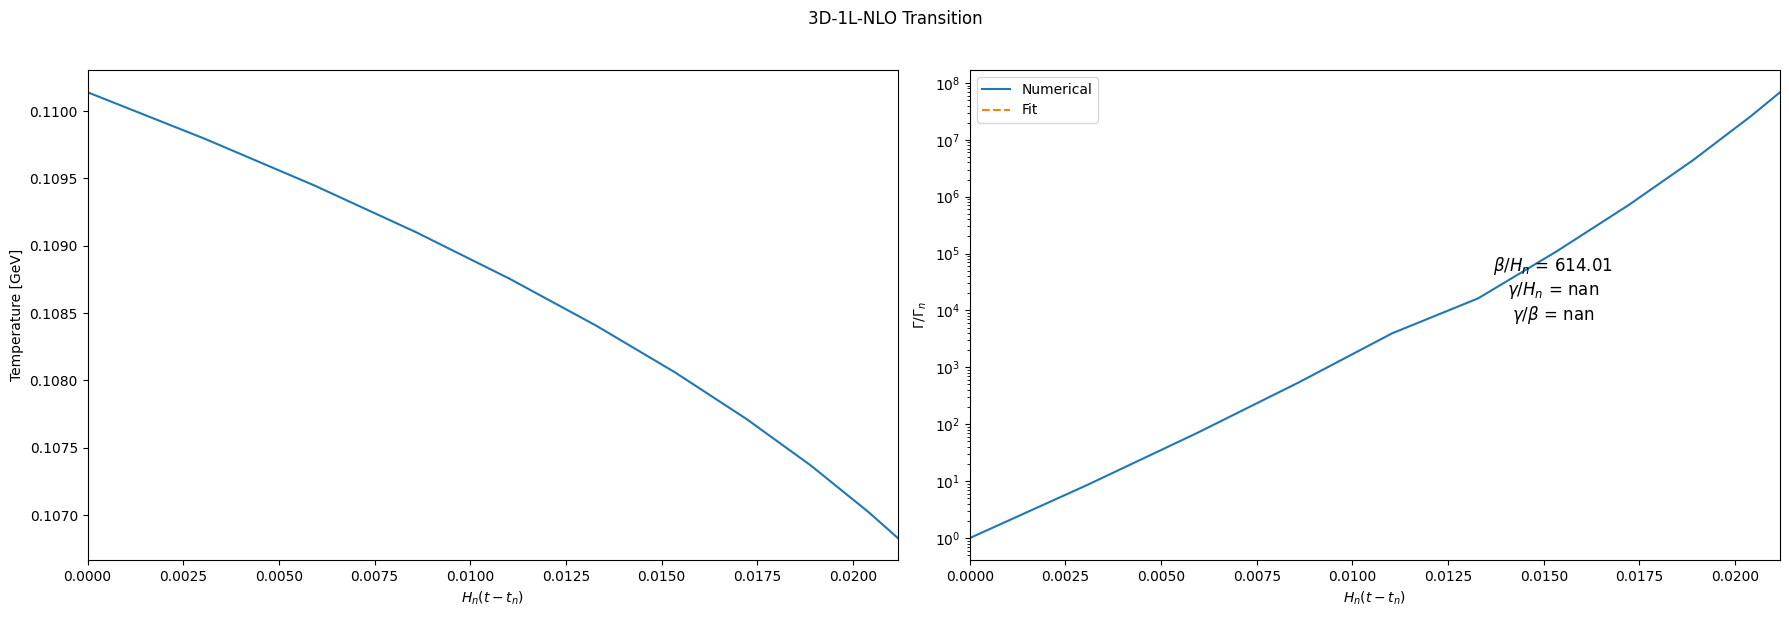

Percolation at 2.12e-02


In [57]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['text.usetex'] = False

if len(times) == 0 or len(Gamma_t) == 0 or len(Temps_t) == 0 or len(H_t) == 0:
    raise RuntimeError("beta(...) returned empty arrays, so the nucleation-fit plot cannot be made.")

Gamma_n = float(Gamma_t[0])
H_n = float(H_t[0])

def scientific_notation(number):
    """Return a string in scientific notation for display."""
    number = float(number)
    if not np.isfinite(number) or number == 0.0:
        return "0"
    exponent = int(np.floor(np.log10(abs(number))))
    coefficient = number / (10 ** exponent)
    return f"{coefficient:.2f} x 10^{exponent}"

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# -------- temperature evolution --------
axes[0].plot(times, Temps_t)
axes[0].set_xlabel(r"$H_n (t - t_n)$")
axes[0].set_ylabel(f"Temperature [{units}]")
axes[0].set_xlim(times[0], times[-1])

# -------- parameter box text --------
beta_dim = beta_Hn * H_n if np.isfinite(beta_Hn) and np.isfinite(H_n) else np.nan
gamma_dim = gamma_Hn * H_n if np.isfinite(gamma_Hn) and np.isfinite(H_n) else np.nan
gamma_over_beta = gamma_Hn / beta_Hn if np.isfinite(gamma_Hn) and np.isfinite(beta_Hn) and beta_Hn != 0 else np.nan

box_text = (
    f"$\\beta$ = {scientific_notation(beta_dim)} {units}\n"
    f"$\\gamma$ = {scientific_notation(gamma_dim)} {units}\n"
    f"$H_n$ = {scientific_notation(H_n)} {units}\n\n"
    f"$\\beta / H_n$ = {beta_Hn:.2f}\n"
    f"$\\gamma / H_n$ = {gamma_Hn:.2f}\n"
    f"$\\gamma / \\beta$ = {gamma_over_beta:.2f}" if np.isfinite(gamma_over_beta)
    else
    f"$\\beta / H_n$ = {beta_Hn:.2f}\n"
    f"$\\gamma / H_n$ = {gamma_Hn:.2f}\n"
    f"$\\gamma / \\beta$ = nan"
)

# -------- Gamma/Gamma_n and fit --------
mask_gamma_plot = np.isfinite(Gamma_t) & (Gamma_t > 0)
if np.any(mask_gamma_plot):
    axes[1].plot(times[mask_gamma_plot], Gamma_t[mask_gamma_plot] / Gamma_n, label="Numerical")

tfit = np.linspace(times[0], times[-1], 200, endpoint=True)
fit_curve = np.exp(beta_Hn * tfit - (gamma_Hn * tfit) ** 2 / 2.0)
fit_curve[~np.isfinite(fit_curve)] = np.nan
fit_curve[fit_curve <= 0] = np.nan
axes[1].plot(tfit, fit_curve, label="Fit", linestyle='--')

axes[1].set_xlabel(r"$H_n (t - t_n)$")
axes[1].set_ylabel(r"$\Gamma / \Gamma_n$")
axes[1].set_yscale('log')
axes[1].set_xlim(times[0], times[-1])

# Put text box inside right panel
axes[1].text(
    0.72, 0.55,
    box_text,
    fontsize='large',
    transform=axes[1].transAxes,
    horizontalalignment='center',
    verticalalignment='center'
)

axes[1].legend()

plt.suptitle(f'{description} Transition', y=1.02)
plt.tight_layout()

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"nucleation_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

print(f"Percolation at {times[-1]:.2e}")

In [58]:
from google.colab import files

uploaded = files.upload()

Saving NG15.pkl to NG15.pkl


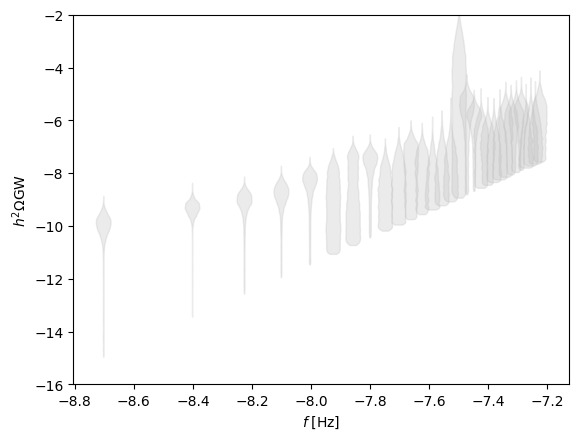

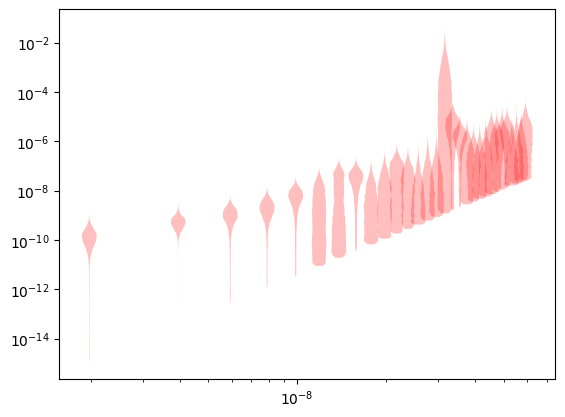

In [59]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
pkl_path = "NG15.pkl"

with open(pkl_path, "rb") as f:
    fig, ax = pickle.load(f)

fig_linear, ax_linear = plt.subplots(figsize=fig.get_size_inches())

for i, collection in enumerate(ax.collections):
    if hasattr(collection, "get_paths") and len(collection.get_paths()) > 0:
        path = collection.get_paths()[0]
        vertices = path.vertices

        if len(vertices) > 0:
            x_log = vertices[:, 0]
            y_log = vertices[:, 1]

            x_linear = 10**x_log
            y_linear = 10**y_log

            ax_linear.fill(
                x_linear,
                y_linear,
                facecolor="red",
                edgecolor="none",
                alpha=0.25,
            )

ax_linear.set_xscale("log")
ax_linear.set_yscale("log")
# Removed redundant xlabel, ylabel, title as X9x6FGjcMrxa will set these

In [60]:
x=(alpha+1)**(1/4)

In [61]:
T_reh=x*T_perc

Is physical? True
g(mu0) = 1.2
lambda(mu0) = 0.0001
mu0 = 1.0 GeV
scheme = 3D-1L-NLO
T_nuc = 0.1102851686338298 GeV
T_perc = 0.10683023250533392 GeV
T_completion = 0.10600625228191615 GeV
Minimal value of P_f = 9.85967654375977e-305 
alpha = 800329.1631777401, alpha_inf = 4260.371313352484, alpha_eq = 2985.90363129526
gamma_star = 3972248387467675.0, gamma_eq = 266.60900355952197
beta/H = 614.0077205203194
Is runaway? True
RH = 0.012213215533743


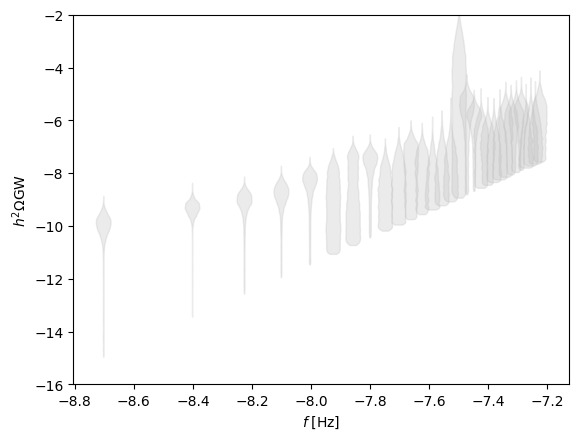

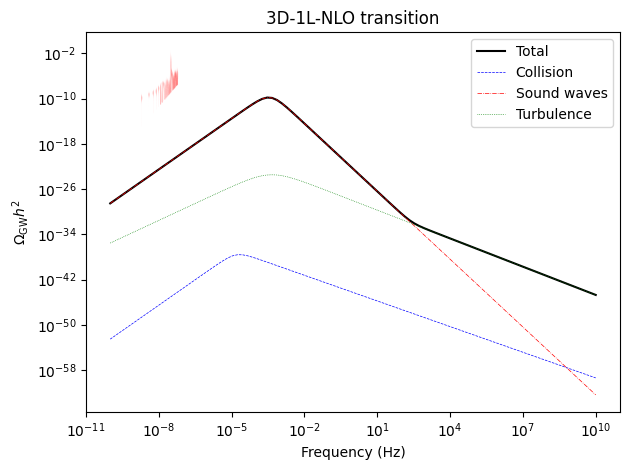

In [62]:
import pickle
from GWparams import GW_SuperCooled
import contextlib
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

def safe_get(name, default=np.nan):
    return globals().get(name, default)

def finite_or_nan(x):
    try:
        x = float(np.asarray(x, dtype=float).squeeze())
        return x if np.isfinite(x) else np.nan
    except Exception:
        return np.nan

beta_H = finite_or_nan(safe_get("beta_Hn"))
gamma_star = finite_or_nan(safe_get("gamma_star", safe_get("gamma_Hn")))
if not np.isfinite(gamma_star):
    gamma_star = 0.0

H_star = finite_or_nan(safe_get("H_star"))
R_star = finite_or_nan(safe_get("R_star"))

def print_params():
    print(f"Is physical? {safe_get('is_physical', True)}")
    print(f"g(mu0) = {g}")
    print(f"lambda(mu0) = {lambda_}")
    print(f"mu0 = 1.0 GeV")
    print(f"scheme = {scheme}")
    print(f"T_nuc = {T_nuc} {units}")
    print(f"T_perc = {T_perc} {units}")
    print(f"T_completion = {T_completion} {units}")
    print(f"Minimal value of P_f = {np.nanmin(np.exp(np.clip(logP_f, -700, 0)))} ")
    print(f"alpha = {alpha}, alpha_inf = {alpha_inf}, alpha_eq = {alpha_eq}")
    print(f"gamma_star = {gamma_star}, gamma_eq = {gamma_eq}")
    print(f"beta/H = {beta_H}")
    print(f"Is runaway? {alpha > alpha_inf}")
    if np.isfinite(R_star) and np.isfinite(H_star):
        print(f"RH = {R_star * H_star}")

os.makedirs(figure_dir, exist_ok=True)

with open(os.path.join(figure_dir, f'{description}.txt'), 'w') as f:
    with contextlib.redirect_stdout(f):
        print_params()

log_freq_min = -10
log_freq_max = 10

# --- Start NG15 data plotting ---
# Load pkl_path (defined in zF09DsYnLlYQ, ensure it's available in global scope if not)
pkl_path = "NG15.pkl"
with open(pkl_path, "rb") as f:
    fig_ng15_original, ax_ng15_original = pickle.load(f)

fig_linear, ax_linear = plt.subplots(figsize=fig_ng15_original.get_size_inches())

for i, collection in enumerate(ax_ng15_original.collections):
    if hasattr(collection, "get_paths") and len(collection.get_paths()) > 0:
        path = collection.get_paths()[0]
        vertices = path.vertices

        if len(vertices) > 0:
            x_log = vertices[:, 0]
            y_log = vertices[:, 1]

            x_linear = 10**x_log
            y_linear = 10**y_log

            ax_linear.fill(
                x_linear,
                y_linear,
                facecolor="red",
                edgecolor="none",
                alpha=0.25,
            )
# --- End NG15 data plotting ---

if np.isfinite(T_perc):

    if not np.isfinite(H_star):
        idx = int(np.nanargmin(np.abs(Temps - T_perc)))
        H_star = float(H[idx])

    if not np.isfinite(R_star):
        R_star = 1.0 / max(beta_H * H_star, 1e-300)

    inst = GW_SuperCooled(
        T_perc,
        alpha,
        alpha_inf,
        alpha_eq,
        R_star,
        gamma_star,
        H_star,
        c_s=np.sqrt(1/3),
        units=units
    )

    print_params()

    x = np.logspace(log_freq_min, log_freq_max, 100)

    ax_linear.plot(x, inst.Omegah2(x), label="Total", color='black')
    ax_linear.plot(x, inst.Omegah2coll(x), label="Collision", linewidth=0.5, color='blue', linestyle='--')
    ax_linear.plot(x, inst.Omegah2sw(x), label="Sound waves", linewidth=0.5, color='red', linestyle='-.')
    ax_linear.plot(x, inst.Omegah2turb(x), label="Turbulence", linewidth=0.5, color='green', linestyle=':')

    ax_linear.autoscale_view(tight=True, scalex=True, scaley=True)
    ax_linear.set_xscale('log')
    ax_linear.set_yscale('log')
    ax_linear.set_xlabel('Frequency (Hz)')
    ax_linear.set_ylabel(r'$\Omega_{\mathrm{GW}} h^2$')
    ax_linear.legend()
    ax_linear.set_title(f'{description} transition', y=1)

    fig_linear.tight_layout()
    fig_linear.savefig(
        os.path.join(figure_dir, f"GW_{description}.pdf"),
        dpi=300,
        bbox_inches='tight'
    )

    if is_physical:
        with open(os.path.join(figure_dir, f'GW_{description}.pkl'), 'wb') as f:
            pickle.dump(inst, f)

else:
    print("T_perc is not finite, so GW spectrum was not computed.")

plt.show()